# Laboratorio 4 - Agrupación: VuelaAlpes

**Curso:** ISIS2611 - Aprendizaje de Máquina  
**Fecha:** 11 de mayo de 2026  
**Integrantes:**
- Cristian Felipe Ochoa Osorio
- Ana Sofía Padilla Daza

---

### Descripción

VuelaAlpes es una aerolínea con operaciones en los Alpes y vuelos internacionales. Tras dos años de baja productividad, inició un proceso de mejora continua basado en encuestas a pasajeros. El objetivo de este laboratorio es aplicar técnicas de **agrupación (clustering)** para identificar patrones de comportamiento que permitan caracterizar distintos tipos de pasajeros, apoyando decisiones en innovación, capacitación y calidad del servicio.

**Actividades:**
1. Exploración y limpieza de datos
2. Modelamiento: Algoritmo K-Means
3. Modelamiento: Algoritmo Agglomerative Clustering
4. Modelamiento: Algoritmo DBSCAN
5. Tabla comparativa y selección del mejor modelo
6. Evaluación cualitativa e interpretación de los grupos
7. Análisis de resultados
8. Uso de IAG


## 0. Librerías

In [115]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Configuración global
RANDOM_STATE = 42
DATA_PATH    = './Datos_VuelaAlpes.csv'

np.random.seed(RANDOM_STATE)

# Diccionario para almacenar resultados comparativos
resultados = {}


Librerías cargadas correctamente.


## 1. Exploración de los Datos

En esta sección aplicamos la metodología CRISP-ML(T) para una inspección sistemática del dataset. Antes de aplicar transformaciones, evaluamos la estructura, calidad e integridad de los datos a través de cuatro dimensiones críticas:

- **Completitud:** presencia de valores nulos o faltantes
- **Unicidad:** identificación de registros duplicados
- **Consistencia:** detección de valores que contradicen las reglas del dominio
- **Validez:** identificación de valores atípicos (outliers) y fuera de rangos esperados

Este análisis exploratorio es esencial para entender las características del dataset y fundamentar decisiones posteriores en la preparación de datos.


### 1.1 Carga del Dataset

In [116]:
df = pd.read_csv(DATA_PATH, sep=',', encoding='latin-1')

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes.to_string())
display(df.head(3))


Shape: 10,000 filas × 23 columnas

Tipos de datos:
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Depa

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0


### 1.2 Estadísticas Descriptivas

In [117]:
print("RESUMEN VARIABLES NUMÉRICAS")
display(df.describe().round(2))

print("\nRESUMEN VARIABLES CATEGÓRICAS")
display(df.describe(include='object'))


RESUMEN VARIABLES NUMÉRICAS


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9975.00
mean,64983.06,39.40,1196.04,2.73,3.07,2.76,3.00,3.22,3.23,3.43,3.36,3.39,3.34,3.64,3.29,3.64,3.28,14.86,15.22
std,37610.21,15.07,1000.59,1.33,1.52,1.39,1.28,1.32,1.35,1.31,1.33,1.29,1.32,1.18,1.26,1.18,1.31,36.78,37.37
min,1.00,7.00,31.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00
25%,32452.00,27.00,416.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,2.00,3.00,2.00,0.00,0.00
50%,64815.50,40.00,846.00,3.00,3.00,3.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,0.00,0.00
75%,97470.00,51.00,1744.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,5.00,4.00,13.00,13.00
max,129879.00,80.00,4963.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,930.00,952.00



RESUMEN VARIABLES CATEGÓRICAS


,Gender,Customer Type,Type of Travel,Class
count,10000,10000,10000,10000
unique,2,2,2,3
top,Female,Loyal Customer,Business travel,Business
freq,5140,8155,6934,4856


### 1.3 Completitud - Análisis de Valores Nulos

Evaluamos la presencia de valores faltantes en el dataset. Identificamos columnas con datos incompletos y cuantificamos su magnitud relativa respecto al total de registros.


In [118]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

if df_nulos.empty:
    print("No se encontraron valores nulos.")
else:
    print(f"{len(df_nulos)} columnas con valores nulos:\n")
    display(df_nulos)

1 columnas con valores nulos:



,Nulos,Porcentaje (%)
Arrival Delay in Minutes,25,0.25


### 1.4 Unicidad - Detección de Registros Duplicados

Verificamos la presencia de filas idénticas o completamente duplicadas en el dataset. La duplicación de registros puede afectar el aprendizaje del modelo e introducir sesgos.


In [119]:
n_dup = df.duplicated().sum()
print(f"Registros duplicados: {n_dup} ({n_dup/len(df)*100:.2f}%)")

if n_dup > 0:
    print("\nEjemplos de duplicados:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(6))
else:
    print("No se encontraron filas duplicadas.")


Registros duplicados: 0 (0.00%)
No se encontraron filas duplicadas.


### 1.5 Consistencia - Variables Categóricas

Inspeccionamos los valores únicos de cada variable categórica para detectar anomalías como errores tipográficos, categorías inesperadas, o valores que contradicen el diccionario de datos definido.


In [120]:
cols_cat = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables categóricas: {len(cols_cat)}\n")
for col in cols_cat:
    vals = df[col].value_counts(dropna=False)
    print(f"{col} ({df[col].nunique()} valores únicos)")
    print(vals.to_string())
    print()


Variables categóricas: 4

── Gender (2 valores únicos) ──
Gender
Female    5140
Male      4860

── Customer Type (2 valores únicos) ──
Customer Type
Loyal Customer       8155
disloyal Customer    1845

── Type of Travel (2 valores únicos) ──
Type of Travel
Business travel    6934
Personal Travel    3066

── Class (3 valores únicos) ──
Class
Business    4856
Eco         4442
Eco Plus     702



### 1.6 Validez - Análisis de Outliers en Variables Numéricas

Aplicamos el método del Rango Intercuartílico (IQR) para identificar valores atípicos.


In [121]:
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_resumen = []
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_resumen.append({
        'Variable': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite Inf.': round(lower, 2), 'Límite Sup.': round(upper, 2),
        'N Outliers': n_out,
        '% Outliers': round(n_out / len(df) * 100, 2)
    })

df_outliers = pd.DataFrame(outlier_resumen)

print(df_outliers.columns)
display(df_outliers.head())


Index(['Variable', 'Q1', 'Q3', 'IQR', 'Límite Inf.', 'Límite Sup.',
       'N Outliers', '% Outliers'],
      dtype='str')


,Variable,Q1,Q3,IQR,Límite Inf.,Límite Sup.,N Outliers,% Outliers
0,id,32452.0,97470.0,65018.0,-65075.0,194997.0,0,0.00
1,Age,27.0,51.0,24.0,-9.0,87.0,0,0.00
2,Flight Distance,416.0,1744.0,1328.0,-1576.0,3736.0,223,2.23
3,Inflight wifi service,2.0,4.0,2.0,-1.0,7.0,0,0.00
4,Departure/Arrival time convenient,2.0,4.0,2.0,-1.0,7.0,0,0.00


#### Boxplots de Variables Numéricas

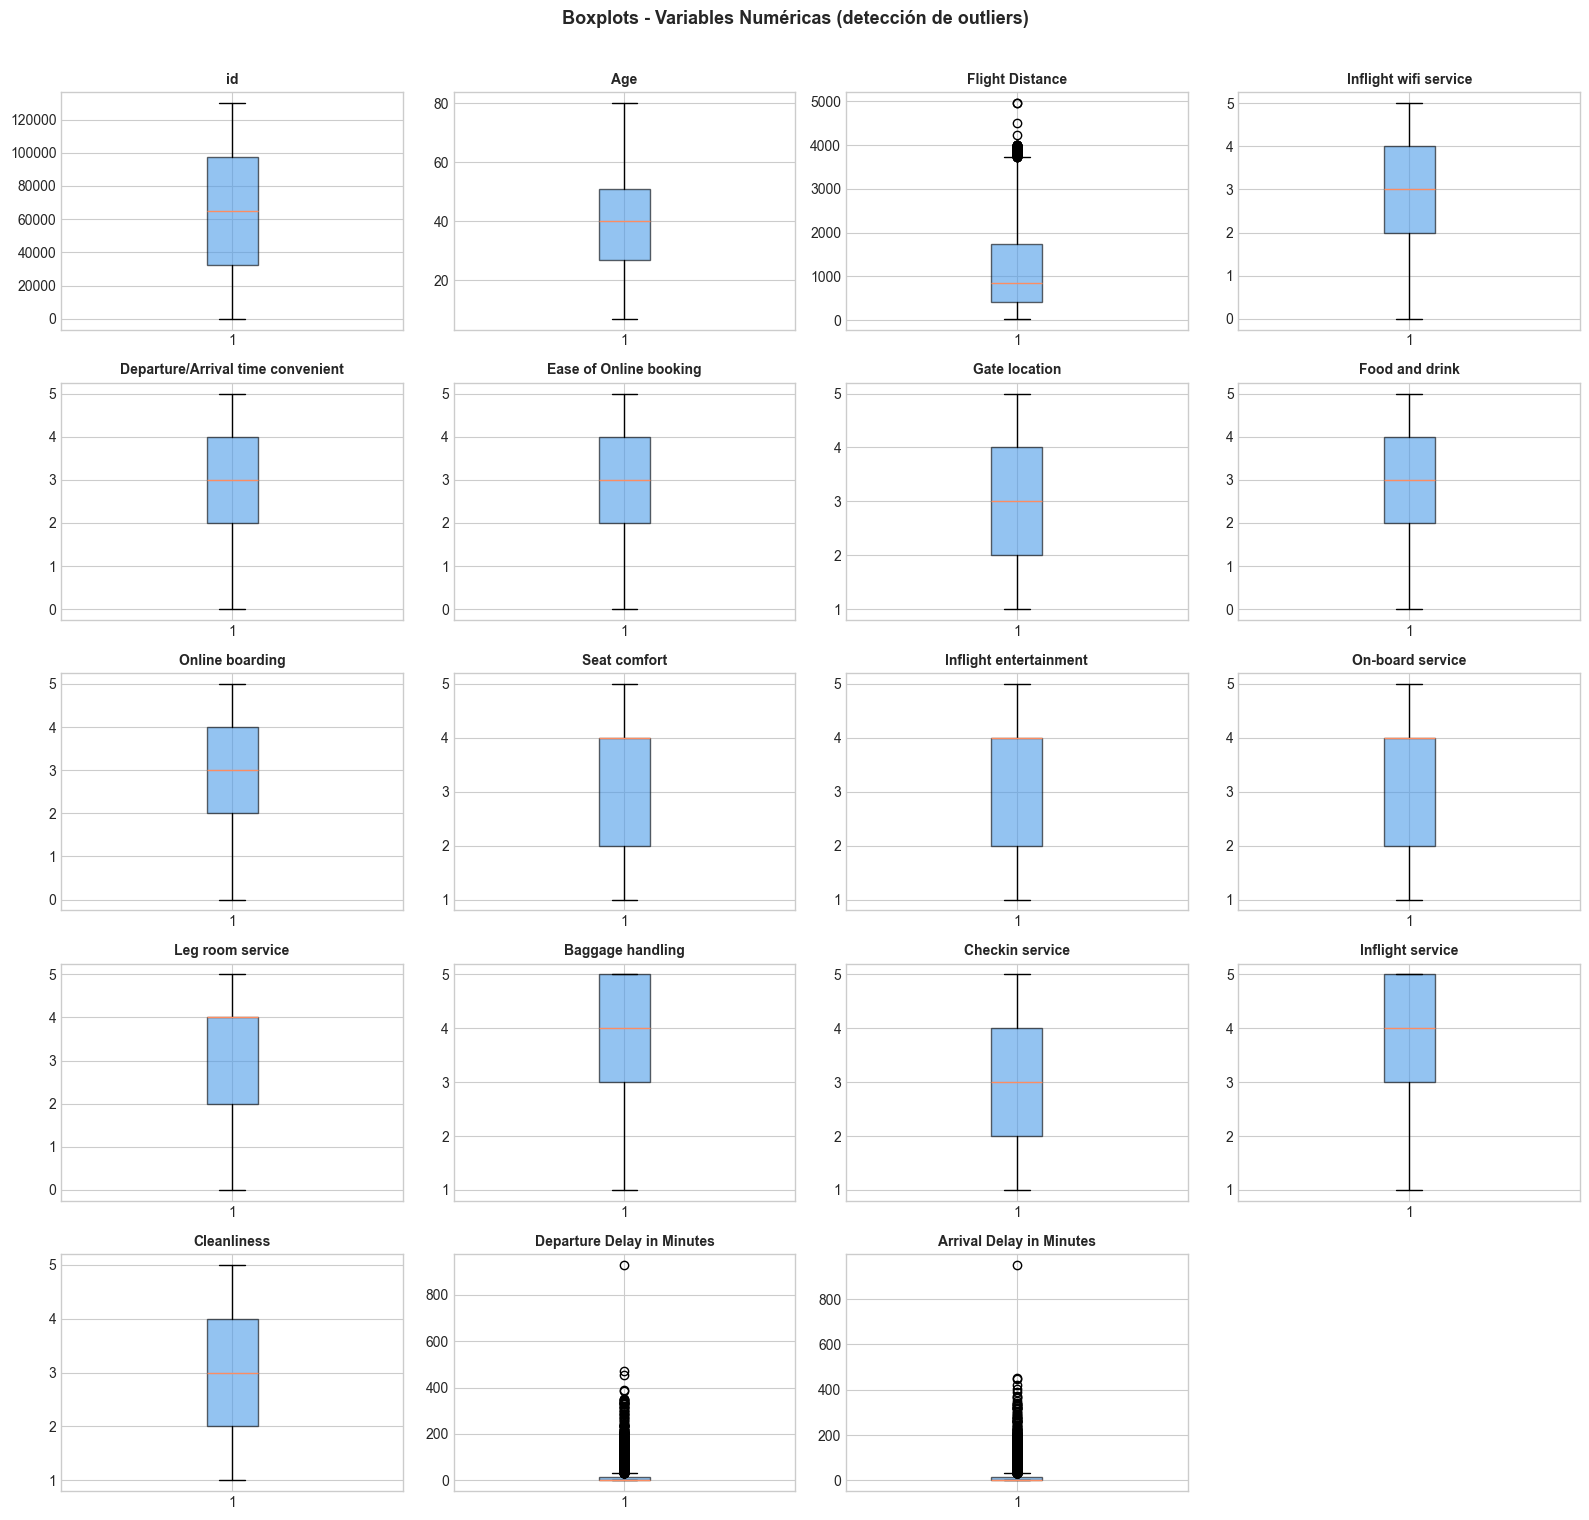

In [122]:
n = len(cols_num)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C9BE8', alpha=0.6))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Variables Numéricas (detección de outliers)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.7 Análisis de Distribuciones - Variables Numéricas

Examinamos la distribución probabilística de cada variable numérica mediante histogramas y gráficos de densidad. Este análisis es esencial para identificar asimetrías, multimodalidad, concentración de valores y comportamientos atípicos que podrían afectar algoritmos de clustering sensibles a la escala.


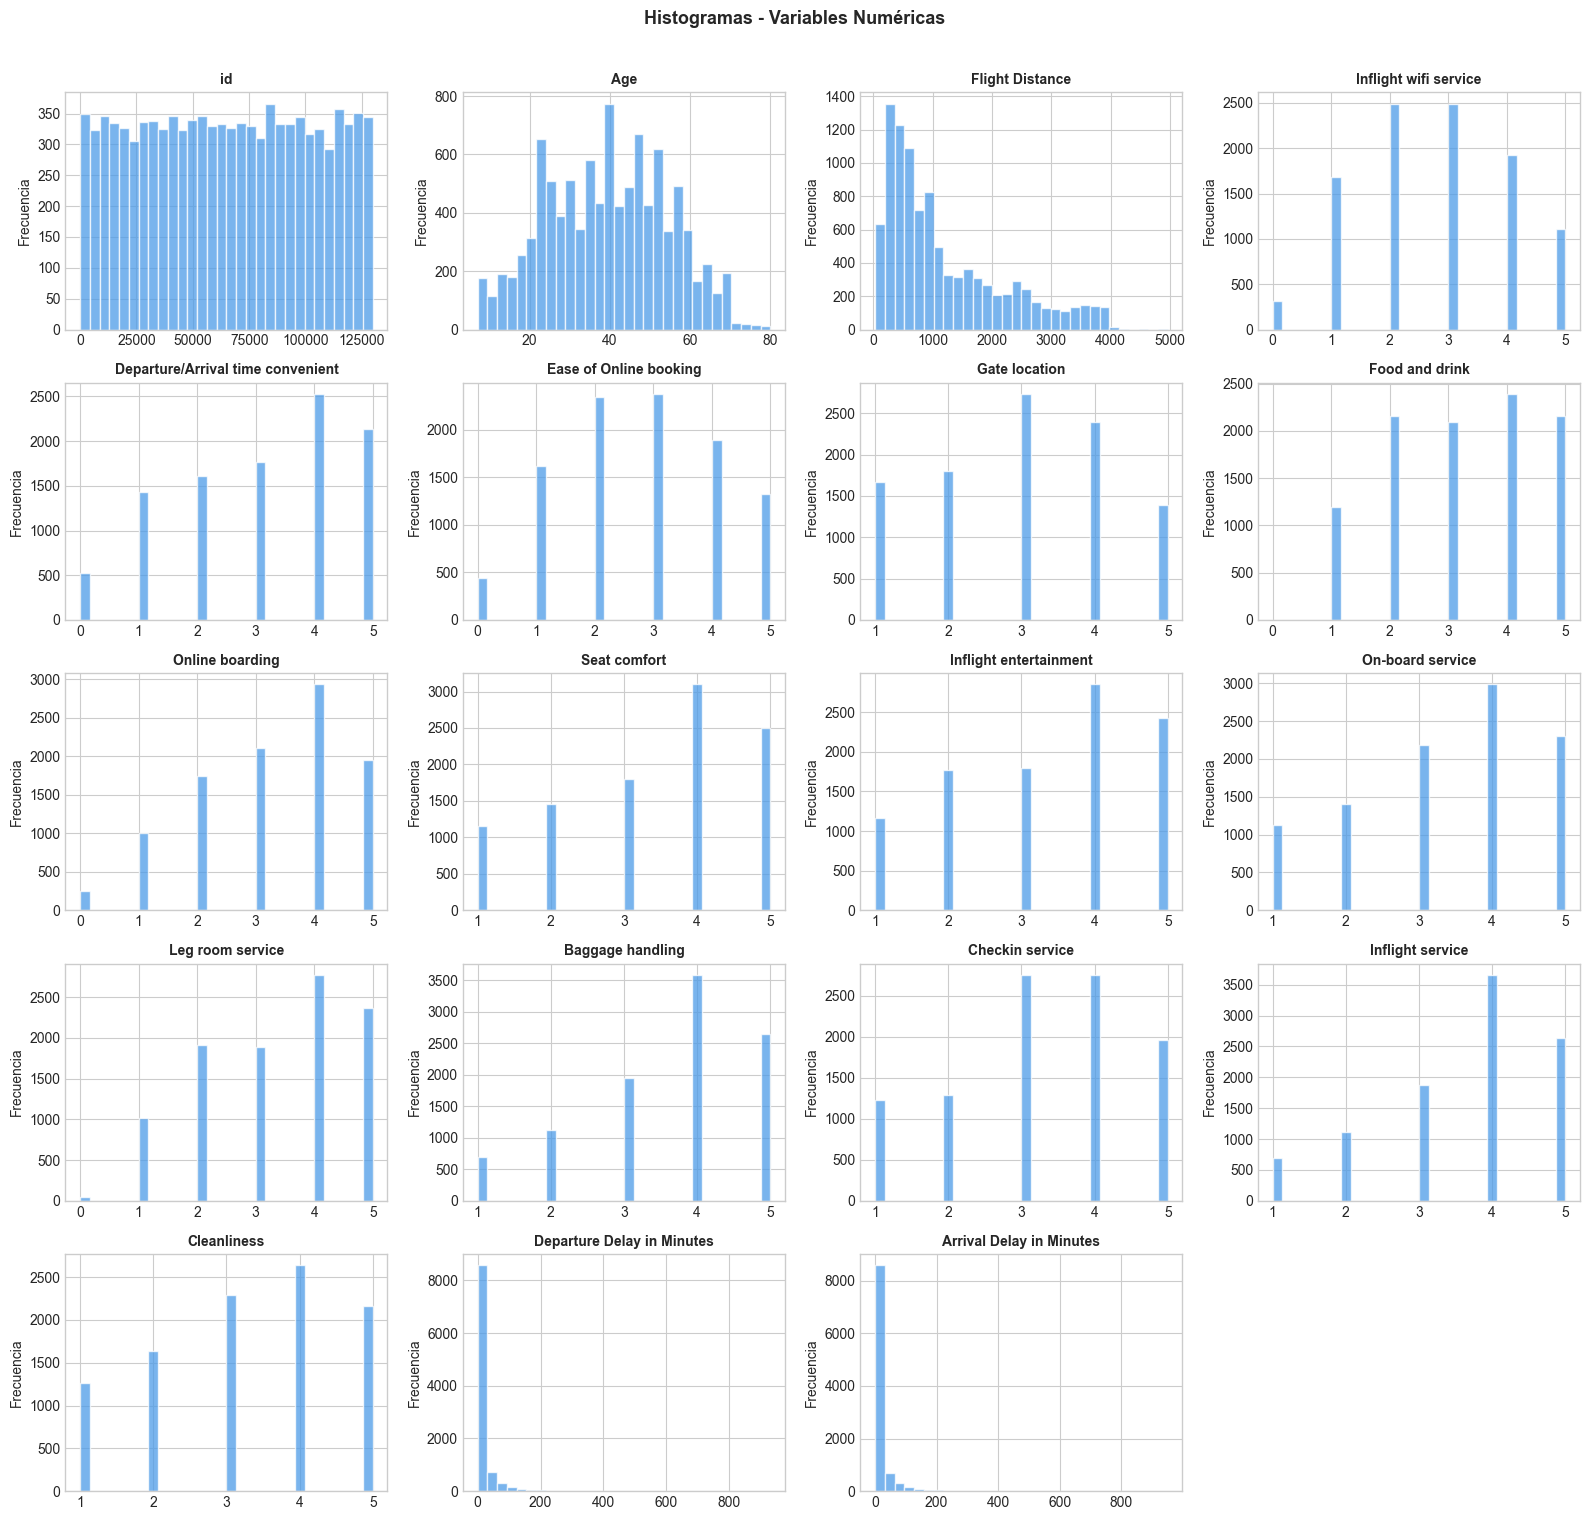

In [123]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].hist(df[col].dropna(), bins=30, color='#4C9BE8', edgecolor='white', alpha=0.75)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas - Variables Numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.8 Análisis de Distribuciones - Variables Categóricas

Analizamos la frecuencia absoluta y relativa de cada categoría en las variables categóricas. Evaluamos el balance o desbalance de clases, que puede influir en la representación de grupos en el clustering.


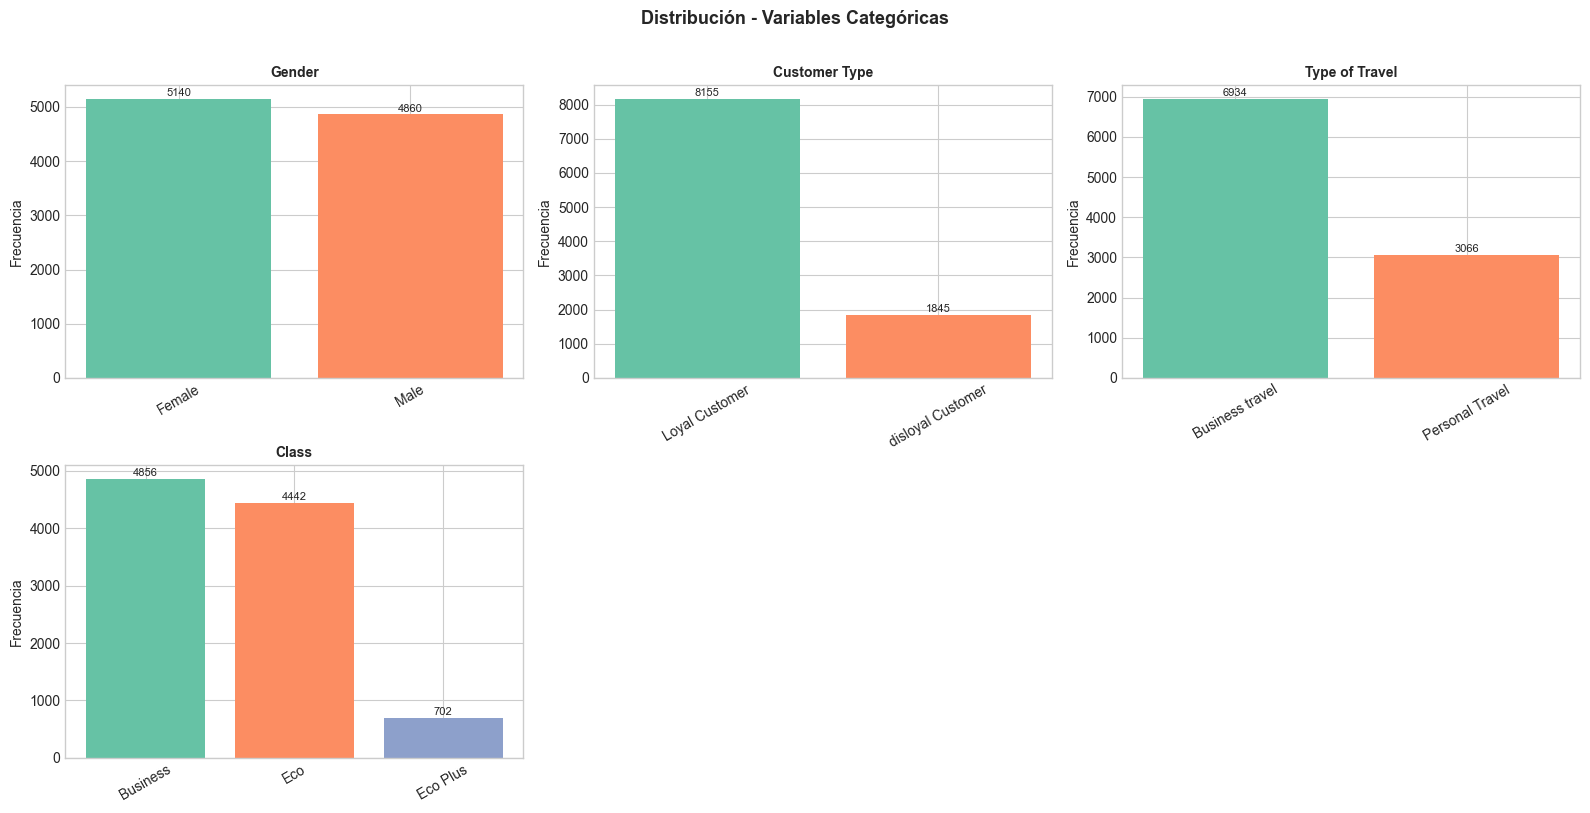

In [124]:
n_cat = len(cols_cat)
ncols_cat = 3
nrows_cat = (n_cat + ncols_cat - 1) // ncols_cat

fig, axes = plt.subplots(nrows_cat, ncols_cat, figsize=(16, nrows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    counts = df[col].value_counts(dropna=False)
    axes[i].bar(counts.index.astype(str), counts.values, 
                color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)
    for k, v in enumerate(counts.values):
        axes[i].text(k, v + max(counts.values) * 0.01, str(v), ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución - Variables Categóricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.9 Análisis de Correlaciones - Variables Numéricas

Calculamos la matriz de correlación de Pearson entre variables numéricas para identificar relaciones lineales. Variables altamente correlacionadas pueden ser redundantes o proporcionar información similar al modelo de clustering.


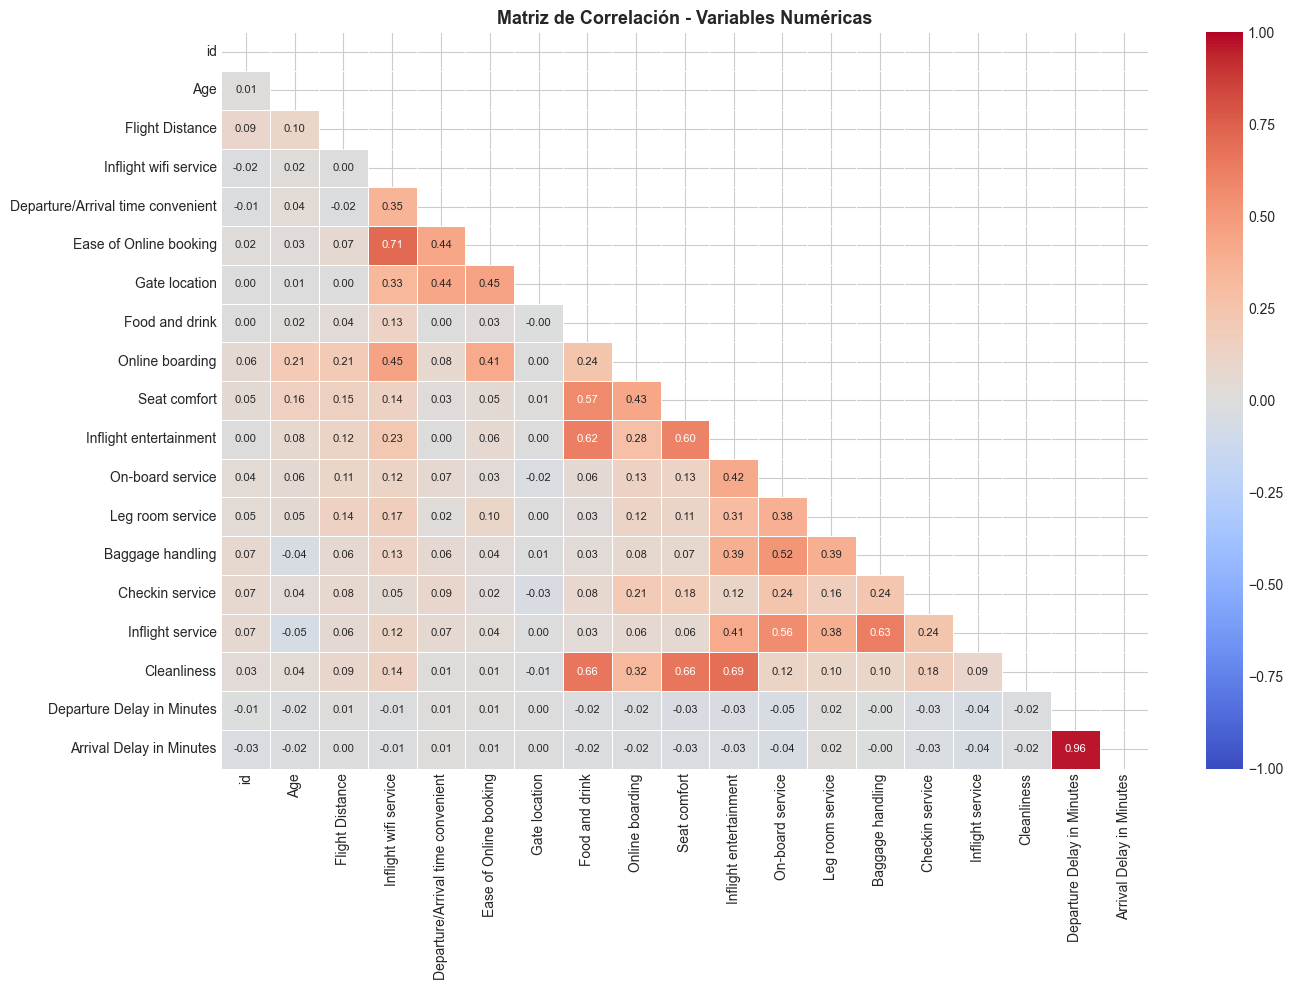

Pares con correlación |r| > 0.7:
  Ease of Online booking  ↔  Inflight wifi service  →  r = 0.714
  Arrival Delay in Minutes  ↔  Departure Delay in Minutes  →  r = 0.962


In [125]:
corr_matrix = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pares con alta correlación
print("Pares con correlación |r| > 0.7:")
for col_a in corr_matrix.columns:
    for col_b in corr_matrix.columns:
        if col_a < col_b:
            r = corr_matrix.loc[col_a, col_b]
            if abs(r) > 0.7:
                print(f"  {col_a}  ↔  {col_b}  →  r = {r:.3f}")


## 2. Limpieza y Preparación de Datos

En esta fase realizamos transformaciones sistemáticas para preparar los datos en un formato adecuado para algoritmos de clustering. Incluye imputación de valores faltantes, normalización/estandarización de escala, codificación de variables categóricas y reducción de dimensionalidad para visualización.


### 2.1 Estrategia de Limpieza

Aplicamos procedimientos de limpieza siguiendo decisiones documentadas en la tabla siguiente. La estrategia se basa en los hallazgos del análisis exploratorio realizado en la sección anterior.


In [126]:
df_clean = df.copy()

# Eliminar columnas no pertinentes
# Columna índice (si existe)
drop_cols = [c for c in df_clean.columns if c.lower() in ['unnamed: 0', 'id']]
if drop_cols:
    df_clean.drop(columns=drop_cols, inplace=True)
    print(f"Columnas índice eliminadas: {drop_cols}")

# Tratar valores nulos 
nulos_antes = df_clean.isnull().sum().sum()
# Imputar columnas numéricas con mediana (robusto a outliers)
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f" '{col}': nulos imputados con mediana ({mediana:.2f})")

# Imputar columnas categóricas con moda
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().any():
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f"  → '{col}': nulos imputados con moda ('{moda}')")

nulos_despues = df_clean.isnull().sum().sum()
print(f"\nNulos antes: {nulos_antes} | Después: {nulos_despues}")

# Eliminar duplicados
n_dup = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"\n Duplicados eliminados: {n_dup}")

# Corregir valores de calificaciones fuera de rango [0,5]
rating_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns
               if df_clean[c].max() <= 6 and df_clean[c].min() >= 0 and df_clean[c].nunique() <= 7]
for col in rating_cols:
    fuera = ((df_clean[col] < 0) | (df_clean[col] > 5)).sum()
    if fuera > 0:
        df_clean[col] = df_clean[col].clip(0, 5)
        print(f"  → '{col}': {fuera} valores recortados al rango [0,5]")

print(f"\nShape final: {df_clean.shape[0]:,} × {df_clean.shape[1]}")


Columnas índice eliminadas: ['id']
 'Arrival Delay in Minutes': nulos imputados con mediana (0.00)

Nulos antes: 25 | Después: 25

 Duplicados eliminados: 0

Shape final: 10,000 × 22


### 2.2 Clasificación de Variables para el Pipeline de Preprocesamiento

Identificamos y clasificamos las variables según su tipo y características, estableciendo estrategias diferenciadas de preprocesamiento: imputación de valores faltantes, normalización/estandarización para numéricas, y codificación para categóricas.


In [127]:
# Separar features por tipo
COLS_NUM = df_clean.select_dtypes(include=[np.number]).columns.tolist()
COLS_CAT = df_clean.select_dtypes(include='object').columns.tolist()

# Columnas binarias (0/1 o dos únicos valores)
COLS_BIN = [c for c in COLS_NUM if df_clean[c].nunique() == 2 and set(df_clean[c].unique()).issubset({0,1})]
COLS_NUM_CONT = [c for c in COLS_NUM if c not in COLS_BIN]

print(f"Variables numéricas continuas ({len(COLS_NUM_CONT)}):")
print(f"  {COLS_NUM_CONT}")
print(f"\nVariables binarias ({len(COLS_BIN)}):")
print(f"  {COLS_BIN}")
print(f"\nVariables categóricas nominales ({len(COLS_CAT)}):")
print(f"  {COLS_CAT}")


Variables numéricas continuas (18):
  ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Variables binarias (0):
  []

Variables categóricas nominales (4):
  ['Gender', 'Customer Type', 'Type of Travel', 'Class']


### 2.3 Pipeline de Preprocesamiento

Construimos un pipeline reproducible que automatiza el preprocesamiento. El pipeline integra estrategias específicas para variables numéricas y categóricas, garantizando consistencia entre entrenamiento y producción.


In [128]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Transformer para numéricas continuas
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Transformer para binarias (escalar sin one-hot)
bin_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  StandardScaler())
])

# Transformer para categóricas nominales
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Lista de transformers (solo incluimos los tipos que existen)
transformers = []
if COLS_NUM_CONT:
    transformers.append(('num', num_transformer, COLS_NUM_CONT))
if COLS_BIN:
    transformers.append(('bin', bin_transformer, COLS_BIN))
if COLS_CAT:
    transformers.append(('cat', cat_transformer, COLS_CAT))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Aplicar preprocesamiento y obtener matriz X_prep para análisis
X_raw  = df_clean.copy()
X_prep = preprocessor.fit_transform(X_raw)

print(f"Preprocesamiento aplicado.")
print(f"   Shape original: {X_raw.shape}")
print(f"   Shape preprocesado: {X_prep.shape}  (columnas expandidas por OneHotEncoder)")


Preprocesamiento aplicado.
   Shape original: (10000, 22)
   Shape preprocesado: (10000, 27)  (columnas expandidas por OneHotEncoder)


### 2.4 Reducción de Dimensionalidad con PCA (para Visualización)

Aplicamos Análisis de Componentes Principales (PCA) al dataset preprocesado para reducir a 2 dimensiones manteniendo la máxima varianza posible. PCA es exclusivamente para visualización (no se utiliza en algoritmos de clustering); los algoritmos operan en el espacio original preprocesado.

**Justificación:** PCA permite visualizar clusters en 2D, facilitando interpretación visual de separación y cohesión, aunque los clusters reales se forman en la dimensionalidad original.


Varianza explicada PCA-2: 31.83%
Varianza explicada PCA-3: 42.94%


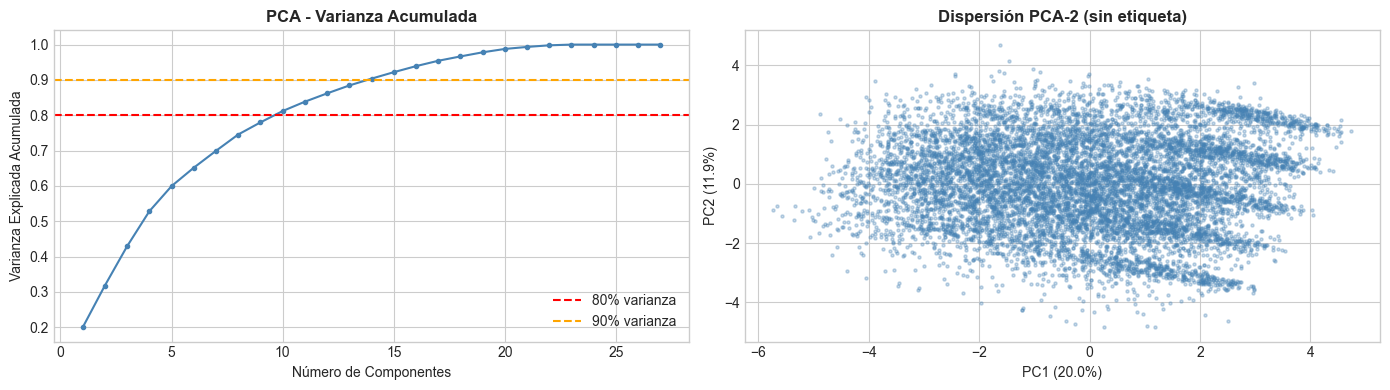

X_prep y X_pca2 disponibles para los modelos de clustering.


In [129]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_prep)

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_prep)

print(f"Varianza explicada PCA-2: {pca2.explained_variance_ratio_.sum():.2%}")
print(f"Varianza explicada PCA-3: {pca3.explained_variance_ratio_.sum():.2%}")

# Curva de varianza acumulada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_prep)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Varianza acumulada
axes[0].plot(range(1, len(var_acum)+1), var_acum, 'o-', color='steelblue', markersize=3)
axes[0].axhline(0.80, color='red', linestyle='--', label='80% varianza')
axes[0].axhline(0.90, color='orange', linestyle='--', label='90% varianza')
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title('PCA - Varianza Acumulada', fontweight='bold')
axes[0].legend()

# Dispersión 2D (sin etiqueta de clusters aún)
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.3, s=5, color='steelblue')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Dispersión PCA-2 (sin etiqueta)', fontweight='bold')

plt.tight_layout()
plt.show()

print("X_prep y X_pca2 disponibles para los modelos de clustering.")


### 2.5 Resumen del Proceso de Preparación

Recapitulamos la estrategia y pasos de preparación de datos:
1. **Imputación:** Valores faltantes imputados con mediana (variables numéricas)
2. **Escalado:** StandardScaler para normalizar variables numéricas
3. **Codificación:** OneHotEncoder para variables categóricas
4. **Validación:** Verificación de forma y tipos de datos del dataset procesado

Este pipeline garantiza reproducibilidad y es aplicable a datos nuevos.


### Función Auxiliar de Evaluación y Visualización

Definimos función `evaluar_modelo()` que centraliza generación de métricas y visualizaciones para cada modelo de clustering. La función calcula métricas de validación (Silhouette, Calinski-Harabasz, Davies-Bouldin), visualiza clusters en espacio PCA y produce tabla de distribución de tamaños de clusters.


In [130]:
def evaluar_modelo(nombre, labels, X_prep, X_pca2):
    mask_validos = labels != -1
    n_clusters = len(set(labels[mask_validos]))
    n_ruido = (labels == -1).sum()
    resultado = {'Algoritmo': nombre, 'N Clusters': n_clusters, 'N Ruido': n_ruido}
    if n_clusters >= 2:
        resultado['Silhouette']        = round(silhouette_score(X_prep[mask_validos], labels[mask_validos]), 4)
        resultado['Calinski-Harabasz'] = round(calinski_harabasz_score(X_prep[mask_validos], labels[mask_validos]), 2)
        resultado['Davies-Bouldin']    = round(davies_bouldin_score(X_prep[mask_validos], labels[mask_validos]), 4)
    else:
        resultado['Silhouette'] = resultado['Calinski-Harabasz'] = resultado['Davies-Bouldin'] = np.nan
    print(f"\n{'='*55}\n  {nombre}\n{'='*55}")
    print(f"  Clusters encontrados : {n_clusters}")
    print(f"  Puntos ruido (-1)    : {n_ruido}  ({n_ruido/len(labels)*100:.1f}%)")
    print(f"  Silhouette Score     : {resultado['Silhouette']}")
    print(f"  Calinski-Harabasz    : {resultado['Calinski-Harabasz']}")
    print(f"  Davies-Bouldin       : {resultado['Davies-Bouldin']}")
    unique, counts = np.unique(labels, return_counts=True)
    print("\n  Distribucion de clusters:")
    for u, c in zip(unique, counts):
        lbl = "Ruido" if u == -1 else f"Cluster {u}"
        print(f"    {lbl}: {c:,} ({c/len(labels)*100:.1f}%)")
    palette = sns.color_palette('tab10', max(n_clusters,2))
    color_map = {lbl: palette[i] for i, lbl in enumerate(sorted(set(labels[mask_validos])))}
    color_map[-1] = (0.7, 0.7, 0.7)
    colors = [color_map[l] for l in labels]
    fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 5))
    if ncols == 1: axes = [axes]
    axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=colors, alpha=0.35, s=6)
    axes[0].set_title(f'{nombre} - Clusters en PCA-2D', fontweight='bold')
    axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
    from matplotlib.patches import Patch
    handles = [Patch(color=color_map[k], label=('Ruido' if k==-1 else f'Cluster {k}')) for k in sorted(color_map)]
    axes[0].legend(handles=handles, loc='best', fontsize=8)
    plt.tight_layout(); plt.show()
    return resultado

print("Funcion auxiliar definida.")


Funcion auxiliar definida.


# 3. Modelamiento - Algoritmos de Agrupación

En esta sección se implementan tres algoritmos de agrupación distintos utilizando pipelines y búsqueda de hiperparámetros:

1. K-Means  
2. Agglomerative Clustering  
3. DBSCAN  

Todos los modelos integran el preprocesamiento dentro de un flujo reproducible.

## Modelo 1 - K-Means

K-Means es un algoritmo de agrupación **particional** que divide iterativamente los datos en *k* clusters minimizando la inercia (suma de distancias cuadráticas de cada punto al centroide más cercano). Operando en tres pasos iterativos: (1) asignación de cada punto al centroide más próximo, (2) recálculo de centroides, (3) repetición hasta convergencia.

### Descripción Teórica

**Mecanismo:** K-Means busca particionar el espacio de características en *k* regiones, cada una representada por su centroide. El algoritmo minimiza la varianza intra-cluster (cohesión).

**Restricciones y Limitaciones Principales:**
- Requiere especificar *k* a priori (número de clusters desconocido a menudo)
- Asume clusters **esféricos** y de tamaño aproximadamente similar
- Es **sensible a la escala** de las variables (requiere normalización)
- Puede converger a **mínimos locales** (mitigado mediante múltiples inicializaciones con `n_init`)
- No maneja bien **outliers extremos** (asignación forzosa a algún cluster)
- Computacionalmente rápido: O(n·k·i) donde i es número de iteraciones

**Criterios de Parada:**
- Convergencia: centroides estabilizan
- Máximo de iteraciones alcanzado
- Cambio de inércia por debajo de tolerancia

**Hiperparámetros Clave:**
- `n_clusters` (k): número de clusters a descubrir
- `n_init`: número de inicializaciones aleatorias (mayor = más robustez)
- `max_iter`: máximo de iteraciones permitidas
- `random_state`: reproducibilidad

**Estrategia de Búsqueda:** Método del Codo (elbow method) + Índice de Silhouette para identificar el *k* óptimo.


### 2.1.1 Búsqueda de Hiperparámetros - Método del Codo e Índice de Silhouette

Evaluamos múltiples valores de *k* (número de clusters) utilizando métricas de validación interna:

- **Inercia:** suma de distancias cuadráticas intra-cluster (menor es mejor, pero decrece monótonamente)
- **Silhouette Score:** mide cohesión y separación de clusters (-1 a 1; mayor es mejor)
- **Calinski-Harabasz:** relación varianza inter/intra-cluster (mayor es mejor)
- **Davies-Bouldin:** similitud promedio entre clusters (menor es mejor)

El punto de inflexión en la curva de inercia ("codo") sugiere el *k* óptimo. Complementamos con Silhouette para validación.


  k= 2 | Inercia: 169,922 | Sil: 0.1404 | CH: 1644.8 | DB: 2.3789
  k= 3 | Inercia: 157,950 | Sil: 0.1067 | CH: 1263.5 | DB: 2.4624
  k= 4 | Inercia: 147,081 | Sil: 0.1139 | CH: 1150.7 | DB: 2.1504
  k= 5 | Inercia: 137,381 | Sil: 0.1148 | CH: 1100.3 | DB: 2.1141
  k= 6 | Inercia: 130,922 | Sil: 0.1152 | CH: 1022.2 | DB: 2.0543
  k= 7 | Inercia: 126,707 | Sil: 0.1117 | CH: 935.5 | DB: 2.1706
  k= 8 | Inercia: 123,112 | Sil: 0.1068 | CH: 866.9 | DB: 2.2119
  k= 9 | Inercia: 120,296 | Sil: 0.1082 | CH: 805.4 | DB: 2.1893
  k=10 | Inercia: 117,719 | Sil: 0.1073 | CH: 755.8 | DB: 2.1892
  k=11 | Inercia: 115,724 | Sil: 0.1074 | CH: 709.1 | DB: 2.1421


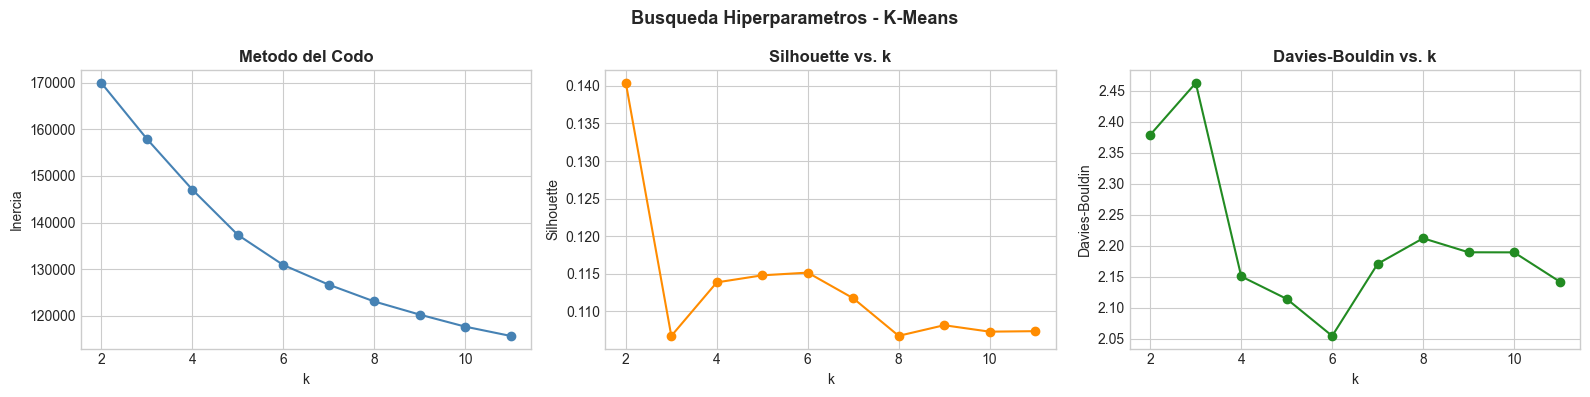


Mejor k seleccionado: 2  (Silhouette = 0.1404)


In [131]:
K_RANGE = range(2, 12)
inercias = []; sil_scores = []; ch_scores = []; db_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels_k = km.fit_predict(X_prep)
    inercias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_prep, labels_k))
    ch_scores.append(calinski_harabasz_score(X_prep, labels_k))
    db_scores.append(davies_bouldin_score(X_prep, labels_k))
    print(f"  k={k:2d} | Inercia: {km.inertia_:,.0f} | Sil: {sil_scores[-1]:.4f} | CH: {ch_scores[-1]:.1f} | DB: {db_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(list(K_RANGE), inercias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].set_title('Metodo del Codo', fontweight='bold')
axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette vs. k', fontweight='bold')
axes[2].plot(list(K_RANGE), db_scores, 'o-', color='forestgreen')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin'); axes[2].set_title('Davies-Bouldin vs. k', fontweight='bold')
plt.suptitle('Busqueda Hiperparametros - K-Means', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"\nMejor k seleccionado: {best_k}  (Silhouette = {max(sil_scores):.4f})")


### 2.1.3 Evaluación K-Means

Presentamos métricas cuantitativas de calidad del clustering y visualizaciones en 2D mediante PCA. Incluimos:
- Cuadro de resultados con métricas de validación
- Gráfico de dispersión en el plano PCA de los clusters
- Distribución de tamaños de cluster
- Análisis de puntos de ruido (si aplica)


In [132]:
pipeline_kmeans = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, max_iter=300))
])
pipeline_kmeans.fit(X_raw)
kmeans_labels = pipeline_kmeans.named_steps['kmeans'].labels_



  K-Means (k=2)
  Clusters encontrados : 2
  Puntos ruido (-1)    : 0  (0.0%)
  Silhouette Score     : 0.1404
  Calinski-Harabasz    : 1644.83
  Davies-Bouldin       : 2.3789

  Distribucion de clusters:
    Cluster 0: 4,573 (45.7%)
    Cluster 1: 5,427 (54.3%)


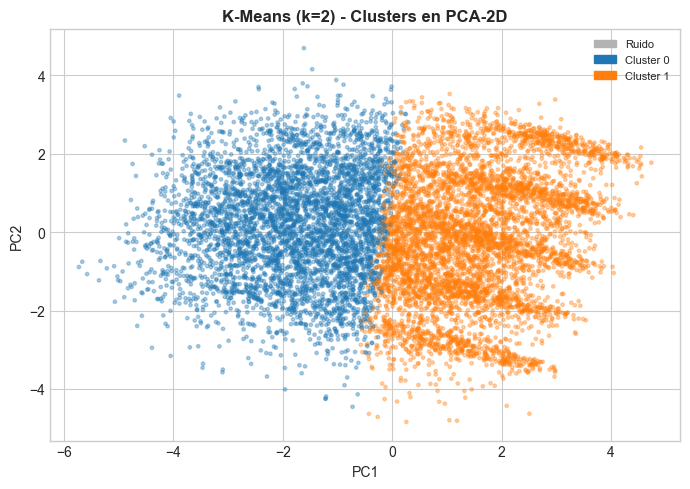

In [133]:
res_kmeans = evaluar_modelo(
    f'K-Means (k={best_k})', kmeans_labels, X_prep, X_pca2
)
resultados['K-Means'] = res_kmeans


### 2.1.4 Perfiles de Clusters K-Means

PERFIL PROMEDIO POR CLUSTER


Cluster_KMeans,0,1
Age,37.47,41.03
Flight Distance,993.40,1366.80
Inflight wifi service,2.27,3.12
Departure/Arrival time convenient,2.95,3.18
Ease of Online booking,2.48,3.00
Gate location,2.96,3.04
Food and drink,2.44,3.87
Online boarding,2.57,3.79
Seat comfort,2.56,4.17
Inflight entertainment,2.27,4.28


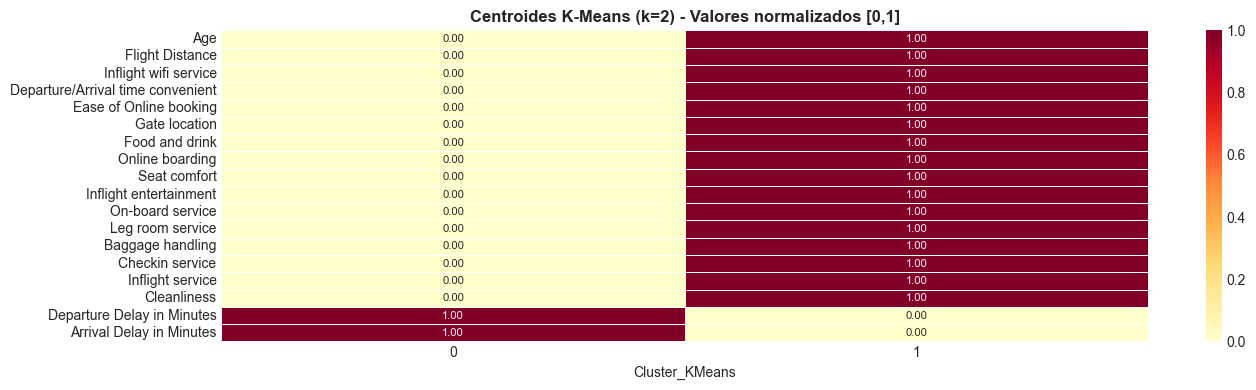


DISTRIBUCION CATEGORICA POR CLUSTER

Gender:


Gender,Female,Male
Cluster_KMeans,,
0,0.522,0.478
1,0.507,0.493



Customer Type:


Customer Type,Loyal Customer,disloyal Customer
Cluster_KMeans,,
0,0.761,0.239
1,0.861,0.139



Type of Travel:


Type of Travel,Business travel,Personal Travel
Cluster_KMeans,,
0,0.603,0.397
1,0.769,0.231


In [134]:
df_perfiles = X_raw.copy()
df_perfiles['Cluster_KMeans'] = kmeans_labels

print("PERFIL PROMEDIO POR CLUSTER")
display(df_perfiles.groupby('Cluster_KMeans')[COLS_NUM_CONT].mean().round(2).T)


scaler_viz = MinMaxScaler()
centroids_raw = df_perfiles.groupby('Cluster_KMeans')[COLS_NUM_CONT].mean()
centroids_norm = pd.DataFrame(scaler_viz.fit_transform(centroids_raw),
    columns=COLS_NUM_CONT, index=centroids_raw.index)

fig, ax = plt.subplots(figsize=(14, max(4, best_k)))
sns.heatmap(centroids_norm.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Centroides K-Means (k={best_k}) - Valores normalizados [0,1]', fontweight='bold')
plt.tight_layout(); plt.show()

if COLS_CAT:
    print("\nDISTRIBUCION CATEGORICA POR CLUSTER")
    for col in COLS_CAT[:3]:
        ct = pd.crosstab(df_perfiles['Cluster_KMeans'], df_perfiles[col], normalize='index').round(3)
        print(f"\n{col}:"); display(ct)


## Modelo 2 - Agglomerative Clustering (Clustering Jerárquico)

El clustering jerárquico aglomerativo construye una jerarquía de clusters mediante un proceso ascendente (bottom-up): comienza con cada punto como cluster individual y sucesivamente fusiona los clusters más cercanos hasta tener un único cluster raíz.

### Descripción Teórica

**Mecanismo:** Utiliza un dendrograma para representar la jerarquía de fusiones. La distancia entre clusters se define mediante criterios de enlace (linkage): completo, simple, promedio o Ward.

**Criterios de Enlace Principales:**
- **Enlace Completo (Complete):** distancia entre los dos puntos más lejanos de clusters distintos (produce clusters más compactos)
- **Enlace Simple (Single):** distancia entre los dos puntos más cercanos (tendencia a cadenas largas)
- **Enlace Promedio (Average):** distancia promedio entre todos pares de puntos
- **Enlace de Ward:** minimiza la varianza intra-cluster (similar a K-Means en resultados)

**Ventajas:**
- No requiere especificar *k* a priori (se elige cortando el dendrograma)
- Proporciona jerarquía completa de agrupaciones
- Determinista (sin componente aleatorio)

**Limitaciones:**
- Computacionalmente más costoso: O(n²) memoria y O(n²) a O(n³) tiempo
- **No es reversible:** una vez fusionados clusters, no se pueden separar
- Sensible a outliers (pueden encadenar clusters)
- Dendrograma puede ser difícil de interpretar con n grande


### 2.2.1 Búsqueda de Hiperparámetros - Criterio de Enlace × Número de Clusters

Evaluamos diferentes combinaciones de:
- **Criterios de enlace:** completo, simple, promedio, Ward
- **Número de clusters (k):** rango de 2 a 11

Comparamos usando métricas de validación interna (Silhouette, Calinski-Harabasz, Davies-Bouldin) para identificar la combinación óptima.


,linkage,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
14,average,2,0.8284,64.03,0.1215
7,complete,2,0.8284,64.03,0.1215
8,complete,3,0.5401,159.24,0.5700
15,average,3,0.4904,188.83,0.6785
16,average,4,0.4762,128.33,0.9303
17,average,5,0.4524,101.32,1.0498
9,complete,4,0.2971,208.04,1.1611
18,average,6,0.2048,81.99,1.2184
19,average,7,0.1505,68.66,1.1438
20,average,8,0.1504,59.08,1.0481


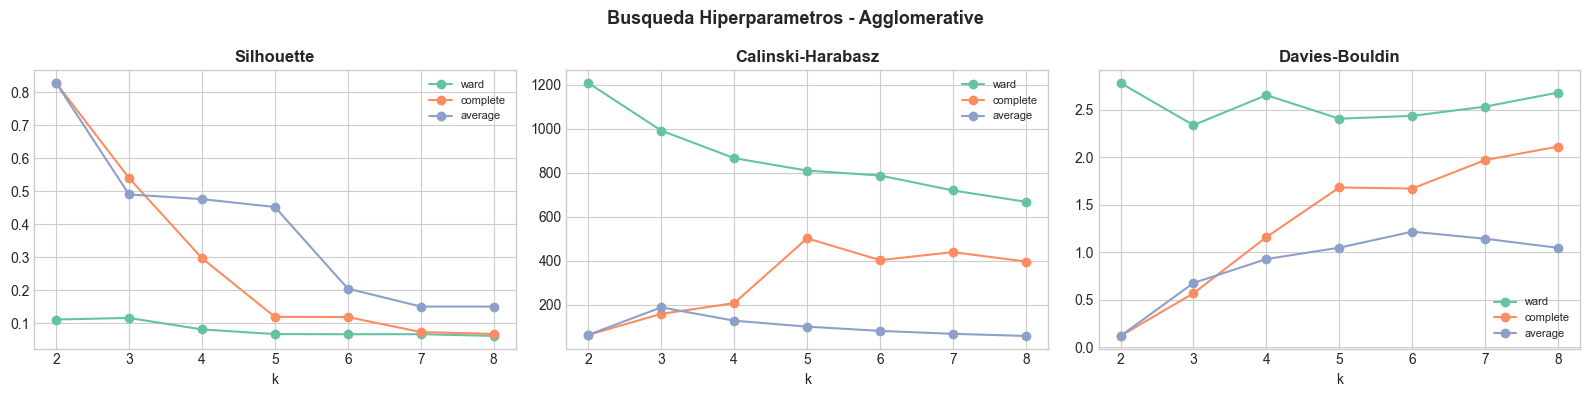


Mejor: linkage='complete', k=2  (Silhouette=0.8284)


In [136]:
LINKAGES = ['ward', 'complete', 'average']
K_RANGE_AGG = range(2, 9)
resultados_agg = []

for link in LINKAGES:
    for k in K_RANGE_AGG:
        try:
            labels_agg_tmp = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X_prep)
            sil = silhouette_score(X_prep, labels_agg_tmp)
            ch  = calinski_harabasz_score(X_prep, labels_agg_tmp)
            db  = davies_bouldin_score(X_prep, labels_agg_tmp)
            resultados_agg.append({'linkage': link, 'k': k,
                'Silhouette': round(sil,4), 'Calinski-Harabasz': round(ch,2), 'Davies-Bouldin': round(db,4)})
        except Exception as e:
            print(f"  Error {link} k={k}: {e}")

df_agg_search = pd.DataFrame(resultados_agg)
display(df_agg_search.sort_values('Silhouette', ascending=False).head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['Silhouette','Calinski-Harabasz','Davies-Bouldin']):
    for link in LINKAGES:
        sub = df_agg_search[df_agg_search['linkage']==link]
        ax.plot(sub['k'], sub[metric], 'o-', label=link)
    ax.set_xlabel('k'); ax.set_title(metric, fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Busqueda Hiperparametros - Agglomerative', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_agg = df_agg_search.loc[df_agg_search['Silhouette'].idxmax()]
best_k_agg = int(best_agg['k']); best_link_agg = best_agg['linkage']
print(f"\nMejor: linkage='{best_link_agg}', k={best_k_agg}  (Silhouette={best_agg['Silhouette']:.4f})")


### 2.2.2 Entrenamiento del Modelo Final Agglomerative

Entrenamos el modelo jerárquico con los hiperparámetros óptimos (número de clusters y criterio de enlace) identificados en la búsqueda anterior.


In [137]:
# AgglomerativeClustering no tiene predict(), se aplica directamente sobre X_prep.
# El pipeline de preprocesamiento queda documentado y reutilizable para nuevos datos.
agg_best = AgglomerativeClustering(n_clusters=best_k_agg, linkage=best_link_agg)
agg_labels = agg_best.fit_predict(X_prep)

print(f"Agglomerative Clustering entrenado.")
print(f"  n_clusters={best_k_agg} | linkage='{best_link_agg}'")


Agglomerative Clustering entrenado.
  n_clusters=2 | linkage='complete'


### 2.2.3 Evaluación y Visualización Agglomerative

Presentamos métricas cuantitativas y visualizaciones para el clustering jerárquico:
- Cuadro de métricas de validación
- Gráfico de dispersión en plano PCA
- Distribución de tamaños de cluster
- Análisis de características dominantes



  Agglomerative (k=2, complete)
  Clusters encontrados : 2
  Puntos ruido (-1)    : 0  (0.0%)
  Silhouette Score     : 0.8284
  Calinski-Harabasz    : 64.03
  Davies-Bouldin       : 0.1215

  Distribucion de clusters:
    Cluster 0: 9,999 (100.0%)
    Cluster 1: 1 (0.0%)


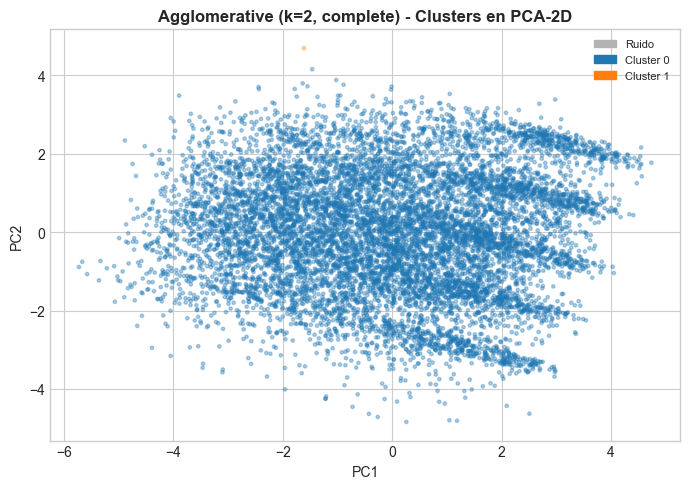

In [138]:
res_agg = evaluar_modelo(
    f'Agglomerative (k={best_k_agg}, {best_link_agg})', agg_labels, X_prep, X_pca2
)
resultados['Agglomerative'] = res_agg


### 2.2.4 Perfiles de Clusters Agglomerative

Caracterizamos cada cluster mediante estadísticas descriptivas. Analizamos el perfil promedio de variables numéricas y la composición categórica de cada grupo.


Cluster_Agg,0,1
Age,39.40,53.0
Flight Distance,1195.92,2418.0
Inflight wifi service,2.73,3.0
Departure/Arrival time convenient,3.07,4.0
Ease of Online booking,2.76,4.0
Gate location,3.00,4.0
Food and drink,3.22,3.0
Online boarding,3.23,3.0
Seat comfort,3.43,3.0
Inflight entertainment,3.36,3.0


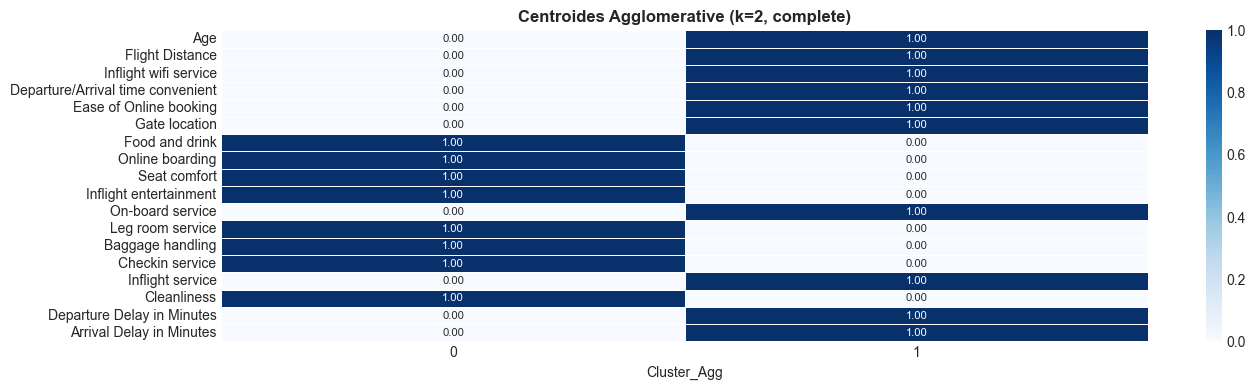

In [139]:
df_perfiles['Cluster_Agg'] = agg_labels
display(df_perfiles.groupby('Cluster_Agg')[COLS_NUM_CONT].mean().round(2).T)

centroids_agg = df_perfiles.groupby('Cluster_Agg')[COLS_NUM_CONT].mean()
centroids_agg_norm = pd.DataFrame(scaler_viz.fit_transform(centroids_agg),
    columns=COLS_NUM_CONT, index=centroids_agg.index)
fig, ax = plt.subplots(figsize=(14, max(4, best_k_agg)))
sns.heatmap(centroids_agg_norm.T, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Centroides Agglomerative (k={best_k_agg}, {best_link_agg})', fontweight='bold')
plt.tight_layout(); plt.show()


## Modelo 3 - DBSCAN (Density-Based Spatial Clustering)

DBSCAN es un algoritmo de clustering **basado en densidad** que agrupa puntos cercanos espacialmente, identificando clusters de forma irregular y clasificando puntos aislados como ruido sin forzar su asignación a clusters.

### Descripción Teórica

**Mecanismo:** Define clusters como regiones densas conectadas. Dos puntos están conectados si están a distancia menor que `eps` y hay una densidad mínima de puntos (`min_samples`). No requiere especificar *k* de antemano.

**Conceptos Clave:**
- **Puntos Núcleo:** tienen al menos `min_samples` vecinos dentro de radio `eps`
- **Puntos Frontera:** no son núcleo pero están a distancia `eps` de alguno
- **Puntos de Ruido:** no son núcleo ni frontera

**Ventajas:**
- Encuentra clusters de **forma arbitraria** (no requiere esfericidad)
- Detecta **outliers** como puntos de ruido (no fuerza asignación)
- No requiere *k* a priori
- Determinista (dado el dataset y parámetros)

**Limitaciones:**
- Muy sensible a hiperparámetros `eps` y `min_samples`
- Dificultad con clusters de **densidades variadas** (mismo eps inadecuado para todos)
- Puede producir muchos puntos de ruido con parámetros inadecuados
- Requiere datos escalados uniformemente

**Hiperparámetros:**
- `eps`: radio de vecindad (se estima con k-distance plot)
- `min_samples`: mínimo de puntos para ser core point (típicamente = dimensión)


### 2.3.1 Selección de eps - Gráfico de k-Distancia

Utilizamos el método del **gráfico de k-distancia** para estimar `eps`: calculamos la distancia al k-ésimo vecino más cercano para cada punto (típicamente k=min_samples), ordenamos estas distancias en forma descendente, y buscamos el "codo" (cambio abrupto) que indica la transición entre puntos de ruido y densidad de cluster.


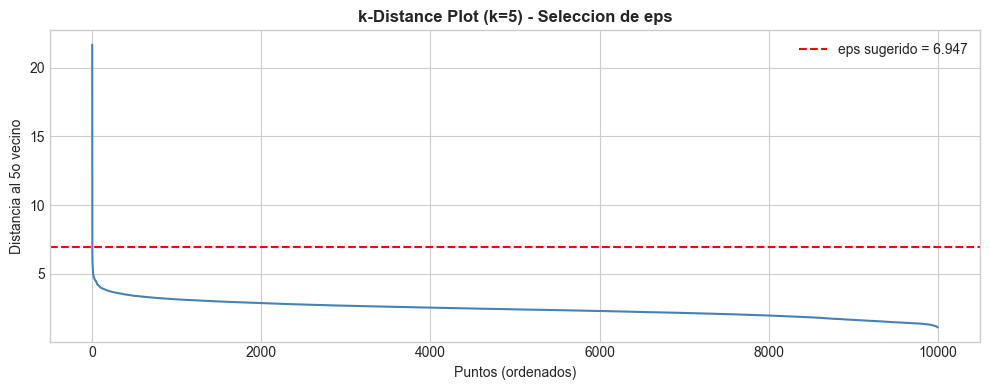

eps sugerido por el codo: 6.947


In [140]:
MIN_SAMPLES_DEFAULT = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_DEFAULT).fit(X_prep)
distances, _ = nbrs.kneighbors(X_prep)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color='steelblue')
ax.set_xlabel('Puntos (ordenados)'); ax.set_ylabel(f'Distancia al {MIN_SAMPLES_DEFAULT}o vecino')
ax.set_title(f'k-Distance Plot (k={MIN_SAMPLES_DEFAULT}) - Seleccion de eps', fontweight='bold')

segunda_deriv = np.diff(np.diff(k_distances))
codo_idx = np.argmax(np.abs(segunda_deriv)) + 1
eps_sugerido = round(k_distances[codo_idx], 3)
ax.axhline(eps_sugerido, color='red', linestyle='--', label=f'eps sugerido = {eps_sugerido}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"eps sugerido por el codo: {eps_sugerido}")


### 2.3.2 Búsqueda de Hiperparámetros - Búsqueda en Grilla

Realizamos búsqueda en grilla sobre:
- **eps:** rango de valores alrededor del codo detectado
- **min_samples:** rango típico (3 a 10)

Evaluamos cada combinación con métricas de validación (ignorando puntos de ruido en cálculos).


In [141]:
EPS_RANGE         = [round(eps_sugerido * f, 3) for f in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]]
MIN_SAMPLES_RANGE = [3, 5, 10, 15]
resultados_dbscan = []

for eps_val in EPS_RANGE:
    for ms in MIN_SAMPLES_RANGE:
        labels_db_tmp = DBSCAN(eps=eps_val, min_samples=ms).fit_predict(X_prep)
        n_cl = len(set(labels_db_tmp)) - (1 if -1 in labels_db_tmp else 0)
        n_ru = (labels_db_tmp == -1).sum()
        mask = labels_db_tmp != -1
        if n_cl >= 2 and mask.sum() > 10:
            sil = round(silhouette_score(X_prep[mask], labels_db_tmp[mask]), 4)
            ch  = round(calinski_harabasz_score(X_prep[mask], labels_db_tmp[mask]), 2)
            db  = round(davies_bouldin_score(X_prep[mask], labels_db_tmp[mask]), 4)
        else:
            sil = ch = db = np.nan
        resultados_dbscan.append({'eps': eps_val, 'min_samples': ms, 'N Clusters': n_cl,
            '% Ruido': round(n_ru/len(labels_db_tmp)*100,1),
            'Silhouette': sil, 'Calinski-Harabasz': ch, 'Davies-Bouldin': db})

df_dbscan_search = pd.DataFrame(resultados_dbscan)
display(df_dbscan_search.sort_values('Silhouette', ascending=False).head(12))


,eps,min_samples,N Clusters,% Ruido,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,3.474,3,3,1.4,0.3217,17.98,0.7519
1,3.474,5,1,1.8,NaN,NaN,NaN
2,3.474,10,1,2.3,NaN,NaN,NaN
3,3.474,15,1,2.7,NaN,NaN,NaN
4,5.210,3,1,0.0,NaN,NaN,NaN
5,5.210,5,1,0.0,NaN,NaN,NaN
6,5.210,10,1,0.0,NaN,NaN,NaN
7,5.210,15,1,0.1,NaN,NaN,NaN
8,6.947,3,1,0.0,NaN,NaN,NaN
9,6.947,5,1,0.0,NaN,NaN,NaN


### 2.3.3 Selección de la Mejor Configuración DBSCAN

Seleccionamos la configuración óptima basada en el balance entre:
- Cohesión y separación (Silhouette Score)
- Proporción aceptable de ruido (balance: no demasiado ruido, pero detecta anomalías)
- Complejidad y interpretabilidad


In [142]:
df_dbscan_valid = df_dbscan_search[
    (df_dbscan_search['N Clusters'] >= 2) &
    (df_dbscan_search['% Ruido'] < 30) &
    (df_dbscan_search['Silhouette'].notna())
].copy()

if df_dbscan_valid.empty:
    print("Relajando filtro de ruido...")
    df_dbscan_valid = df_dbscan_search[df_dbscan_search['Silhouette'].notna()].copy()

best_row    = df_dbscan_valid.loc[df_dbscan_valid['Silhouette'].idxmax()]
best_eps    = best_row['eps']
best_ms     = int(best_row['min_samples'])


Mejor configuracion DBSCAN:
  eps=3.474 | min_samples=3 | N Clusters=3 | % Ruido=1.4% | Silhouette=0.3217


### 2.3.4 Entrenamiento del Modelo Final DBSCAN

Entrenamos DBSCAN con los hiperparámetros óptimos identificados en la búsqueda anterior.


In [143]:
dbscan_best   = DBSCAN(eps=best_eps, min_samples=best_ms)
dbscan_labels = dbscan_best.fit_predict(X_prep)
n_cl_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN entrenado: eps={best_eps} | min_samples={best_ms} | N Clusters={n_cl_db}")


DBSCAN entrenado: eps=3.474 | min_samples=3 | N Clusters=3


### 2.3.5 Evaluación y Visualización DBSCAN

Presentamos resultados del clustering basado en densidad:
- Métricas de validación
- Visualización 2D con puntos de ruido destacados
- Análisis de distribución de tamaños y ruido



  DBSCAN (eps=3.474, ms=3)
  Clusters encontrados : 3
  Puntos ruido (-1)    : 141  (1.4%)
  Silhouette Score     : 0.3217
  Calinski-Harabasz    : 17.98
  Davies-Bouldin       : 0.7519

  Distribucion de clusters:
    Ruido: 141 (1.4%)
    Cluster 0: 9,853 (98.5%)
    Cluster 1: 3 (0.0%)
    Cluster 2: 3 (0.0%)


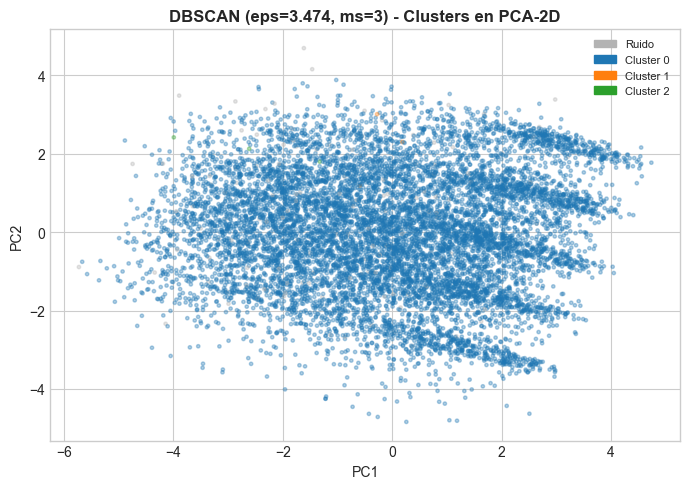

In [144]:
res_dbscan = evaluar_modelo(
    f'DBSCAN (eps={best_eps}, ms={best_ms})', dbscan_labels, X_prep, X_pca2
)
resultados['DBSCAN'] = res_dbscan


### 2.3.6 Perfiles de Clusters DBSCAN

Caracterizamos cada cluster (excluyendo puntos de ruido). Comparamos perfiles estadísticos y categóricos, incluyendo análisis específico de los puntos clasificados como ruido.


Cluster_DBSCAN,0,1,2
Age,39.42,45.67,21.67
Flight Distance,1193.07,973.00,609.00
Inflight wifi service,2.74,3.33,3.00
Departure/Arrival time convenient,3.08,4.00,3.00
Ease of Online booking,2.77,4.00,3.00
Gate location,3.00,4.33,3.67
Food and drink,3.22,3.33,3.00
Online boarding,3.24,3.33,2.33
Seat comfort,3.44,3.00,2.00
Inflight entertainment,3.37,2.67,1.33


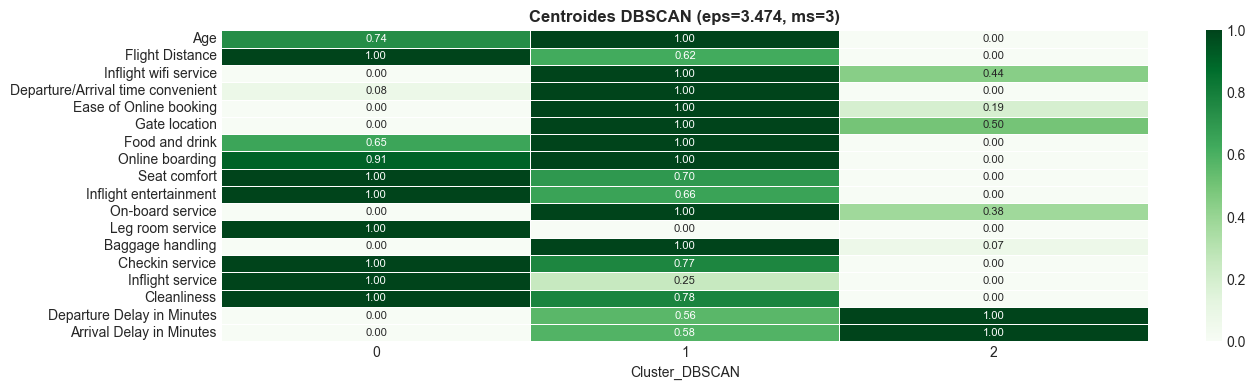

In [145]:
df_perfiles['Cluster_DBSCAN'] = dbscan_labels
df_dbscan_clean = df_perfiles[df_perfiles['Cluster_DBSCAN'] != -1]
display(df_dbscan_clean.groupby('Cluster_DBSCAN')[COLS_NUM_CONT].mean().round(2).T)

centroids_db = df_dbscan_clean.groupby('Cluster_DBSCAN')[COLS_NUM_CONT].mean()
if not centroids_db.empty:
    centroids_db_norm = pd.DataFrame(scaler_viz.fit_transform(centroids_db),
        columns=COLS_NUM_CONT, index=centroids_db.index)
    fig, ax = plt.subplots(figsize=(14, max(4, len(centroids_db))))
    sns.heatmap(centroids_db_norm.T, annot=True, fmt='.2f', cmap='Greens',
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'Centroides DBSCAN (eps={best_eps}, ms={best_ms})', fontweight='bold')
    plt.tight_layout(); plt.show()


## 4. Tabla Comparativa - Evaluación Cuantitativa

Sintetizamos los resultados cuantitativos de los tres algoritmos mediante métricas de validación interna estándar. Esta tabla facilita la comparación objetiva basada en métricas numéricas, aunque la interpretación debe complementarse con análisis cualitativo de los perfiles de clusters y aplicabilidad al negocio.


,Hiperparametros,N Clusters,N Ruido,Silhouette,Calinski-Harabasz,Davies-Bouldin
Algoritmo,,,,,,
K-Means (k=2),"k=2, n_init=10",2,0,0.1404,1644.83,2.3789
"Agglomerative (k=2, complete)","k=2, linkage=complete",2,0,0.8284,64.03,0.1215
"DBSCAN (eps=3.474, ms=3)","eps=3.474, min_samples=3",3,141,0.3217,17.98,0.7519



Mejor Silhouette       : Agglomerative (k=2, complete)
Mejor Calinski-Harabasz: K-Means (k=2)
Mejor Davies-Bouldin   : Agglomerative (k=2, complete)


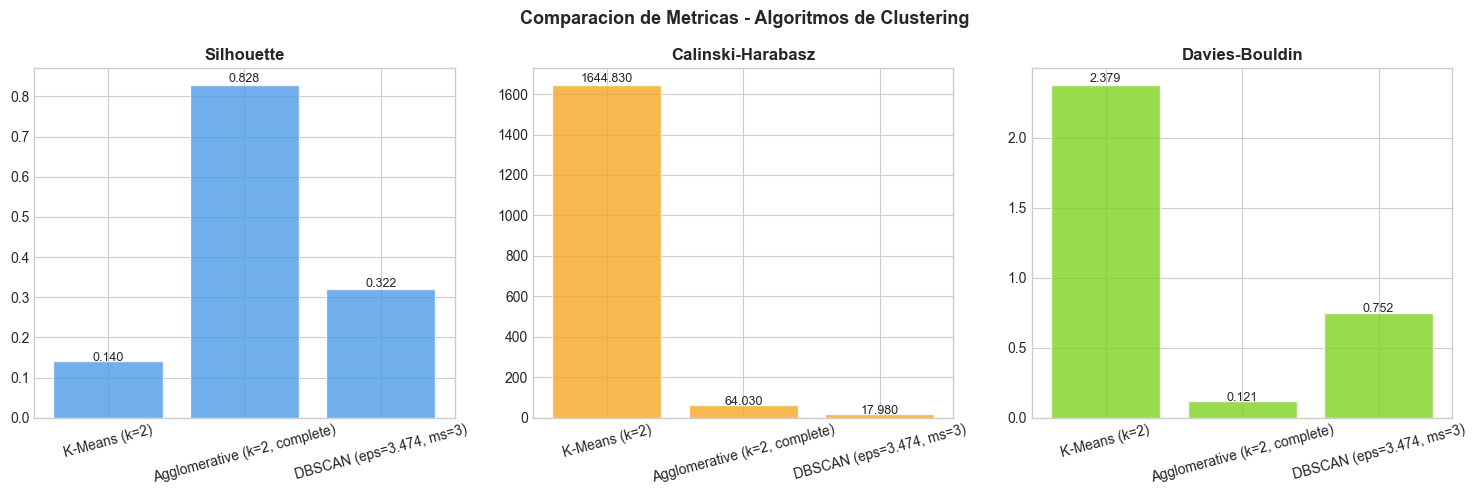

In [146]:
df_comparativa = pd.DataFrame(list(resultados.values()))
hp_map = {
    'K-Means':       f'k={best_k}, n_init=10',
    'Agglomerative': f'k={best_k_agg}, linkage={best_link_agg}',
    'DBSCAN':        f'eps={best_eps}, min_samples={best_ms}'
}
# Coincide clave con nombre completo (usar startswith)
def get_hp(nombre):
    for k,v in hp_map.items():
        if k in nombre: return v
    return '-'
df_comparativa['Hiperparametros'] = df_comparativa['Algoritmo'].apply(get_hp)
cols_tabla = ['Algoritmo','Hiperparametros','N Clusters','N Ruido','Silhouette','Calinski-Harabasz','Davies-Bouldin']
df_comparativa = df_comparativa[cols_tabla]
display(df_comparativa.set_index('Algoritmo'))

print("\nMejor Silhouette       :", df_comparativa.loc[df_comparativa['Silhouette'].idxmax(), 'Algoritmo'])
print("Mejor Calinski-Harabasz:", df_comparativa.loc[df_comparativa['Calinski-Harabasz'].idxmax(), 'Algoritmo'])
print("Mejor Davies-Bouldin   :", df_comparativa.loc[df_comparativa['Davies-Bouldin'].idxmin(), 'Algoritmo'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_viz = [('Silhouette','#4C9BE8'), ('Calinski-Harabasz','#F5A623'), ('Davies-Bouldin','#7ED321')]
for ax, (metric, color) in zip(axes, metricas_viz):
    vals = df_comparativa[metric].fillna(0)
    bars = ax.bar(df_comparativa['Algoritmo'], vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{val:.3f}', ha='center', fontsize=9)
plt.suptitle('Comparacion de Metricas - Algoritmos de Clustering', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Selección y Justificación del Mejor Modelo

Basándose en el análisis comparativo de métricas y las características intrínsecas de cada algoritmo, seleccionamos el modelo óptimo. La selección balancea criterios numéricos (métricas de validación), interpretabilidad, robustez y alineación con objetivos del negocio (VuelaAlpes).


# 5. Evaluación Cualitativa - Interpretación de los Grupos

La evaluación cualitativa consiste en analizar el perfil de cada cluster obtenido por el **mejor modelo** y relacionarlo con los objetivos de negocio de VuelaAlpes: **innovación, capacitación y calidad**.

Para cada cluster se describe:
- Características demográficas predominantes (edad, género, tipo de cliente)
- Tipo de viaje y clase
- Puntos fuertes y débiles en la experiencia de vuelo
- Interpretación del perfil de pasajero
- Recomendaciones para VuelaAlpes


### 5.1 Preparación - Perfil Consolidado del Mejor Modelo

Extraemos los resultados del modelo seleccionado como óptimo. Este perfil consolidado sirve como base para todas las interpretaciones cualitativas y recomendaciones posteriores dirigidas a VuelaAlpes.


In [147]:
best_labels = kmeans_labels
best_model_name = f'K-Means (k={best_k})'

# Añadir etiquetas al dataframe limpio
df_eval = X_raw.copy()
df_eval['Cluster'] = best_labels

# Excluir ruido si aplica (DBSCAN)
df_eval_clean = df_eval[df_eval['Cluster'] != -1].copy()

print(f"Modelo evaluado: {best_model_name}")
print(f"Total pasajeros analizados: {len(df_eval_clean):,}")
print(f"\nDistribución de clusters:")
dist = df_eval_clean['Cluster'].value_counts().sort_index()
for k, v in dist.items():
    print(f"  Cluster {k}: {v:,} pasajeros ({v/len(df_eval_clean)*100:.1f}%)")


Modelo evaluado: K-Means (k=2)
Total pasajeros analizados: 10,000

Distribución de clusters:
  Cluster 0: 4,573 pasajeros (45.7%)
  Cluster 1: 5,427 pasajeros (54.3%)


### 5.2 Perfiles Numéricos por Cluster

Analizamos estadísticas descriptivas de variables numéricas para cada cluster. Incluimos media, mediana, desviación estándar y cuartiles para entender el rango y distribución de valores en cada grupo.


=== PERFIL NUMÉRICO PROMEDIO POR CLUSTER ===


Cluster,0,1
Age,37.47,41.03
Flight Distance,993.40,1366.80
Inflight wifi service,2.27,3.12
Departure/Arrival time convenient,2.95,3.18
Ease of Online booking,2.48,3.00
Gate location,2.96,3.04
Food and drink,2.44,3.87
Online boarding,2.57,3.79
Seat comfort,2.56,4.17
Inflight entertainment,2.27,4.28


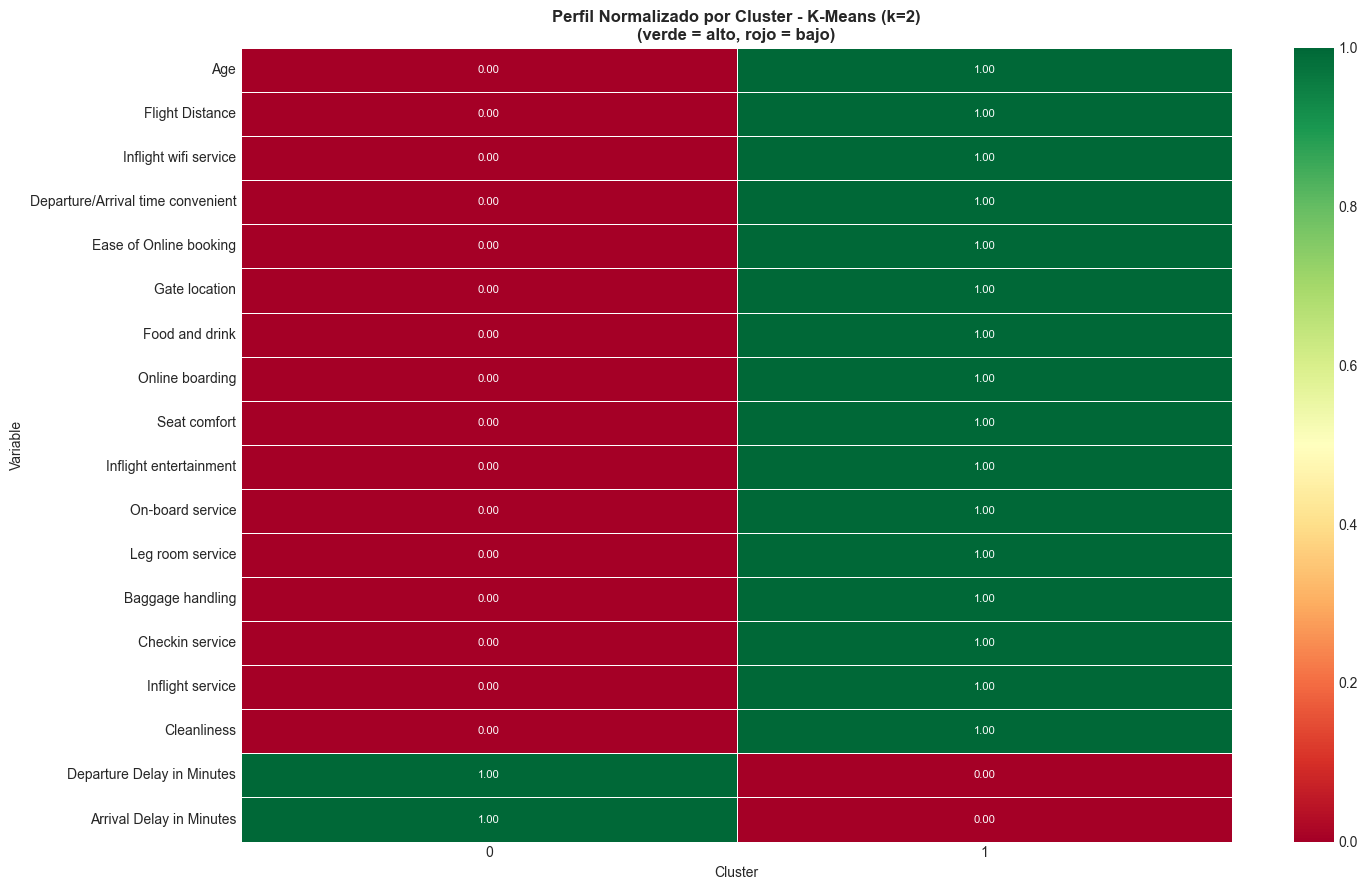

In [ ]:
# Variables numéricas del dataset limpio
cols_num_eval = [c for c in df_eval_clean.columns
                 if c not in ['Gender','Customer Type','Type of Travel','Class','Cluster']]

perfil_num = df_eval_clean.groupby('Cluster')[cols_num_eval].mean().round(2)
print("PERFIL NUMÉRICO PROMEDIO POR CLUSTER")
display(perfil_num.T)

# Heatmap normalizado
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
perfil_norm = pd.DataFrame(
    scaler_viz.fit_transform(perfil_num),
    columns=cols_num_eval,
    index=perfil_num.index
)

fig, ax = plt.subplots(figsize=(15, max(5, len(cols_num_eval)//2)))
sns.heatmap(perfil_norm.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, annot_kws={'size': 8},
            vmin=0, vmax=1, center=0.5)
ax.set_title(f'Perfil Normalizado por Cluster - {best_model_name}\n(verde = alto, rojo = bajo)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster'); ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()


### 5.3 Perfiles Categóricos por Cluster

Analizamos la composición de variables categóricas en cada cluster mediante tablas de frecuencia y distribuciones. Identificamos qué valores categóricos dominan en cada grupo.


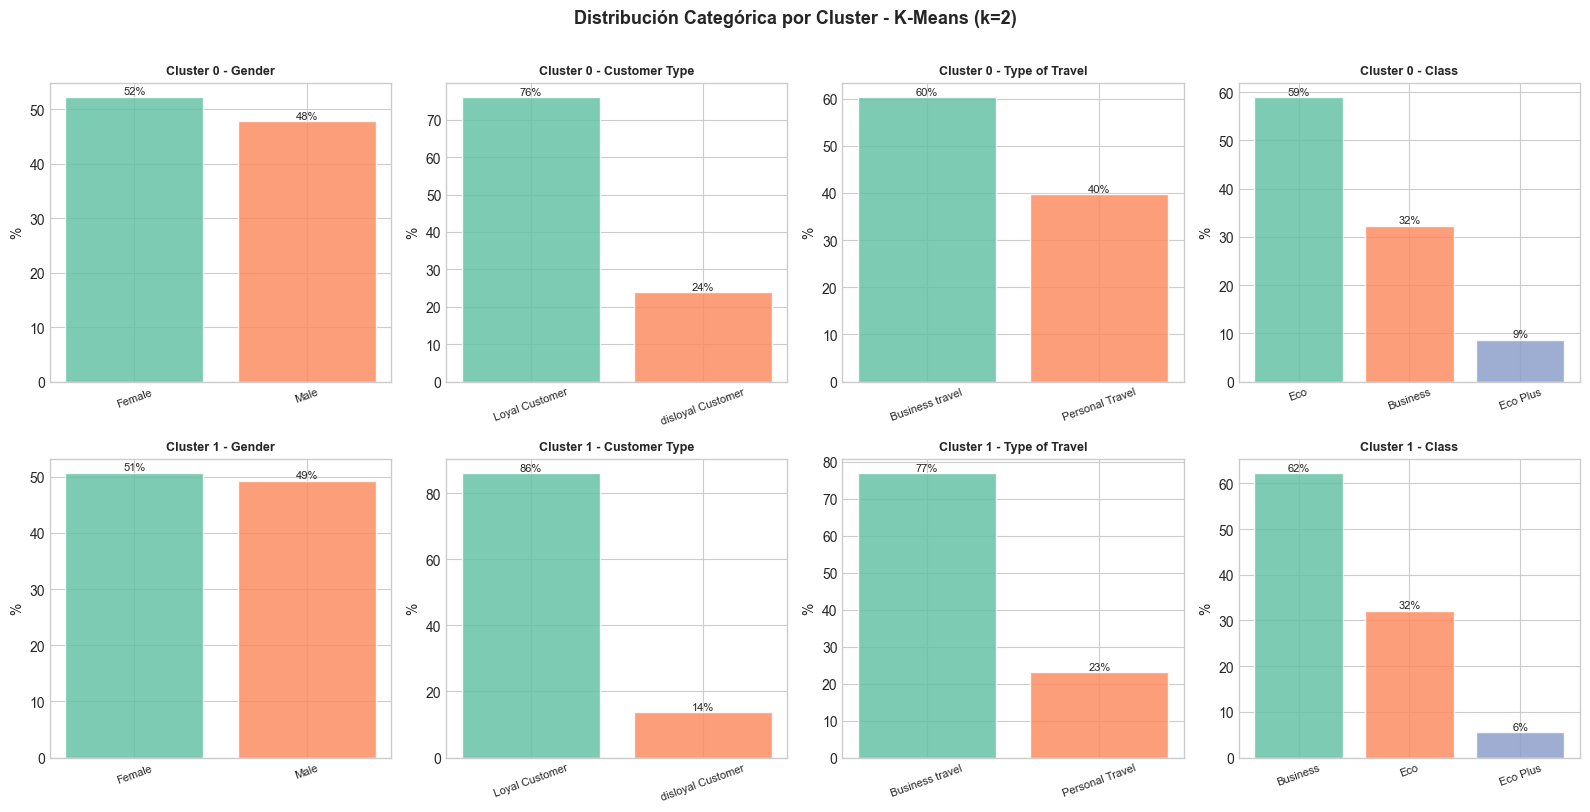

In [149]:
cols_cat_eval = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
n_clusters_best = df_eval_clean['Cluster'].nunique()

fig, axes = plt.subplots(n_clusters_best, len(cols_cat_eval),
                          figsize=(16, 4 * n_clusters_best))
if n_clusters_best == 1:
    axes = axes.reshape(1, -1)

palette = sns.color_palette('Set2')

for i, cluster_id in enumerate(sorted(df_eval_clean['Cluster'].unique())):
    sub = df_eval_clean[df_eval_clean['Cluster'] == cluster_id]
    for j, col in enumerate(cols_cat_eval):
        counts = sub[col].value_counts(normalize=True) * 100
        ax = axes[i][j]
        bars = ax.bar(counts.index, counts.values,
                      color=palette[:len(counts)], edgecolor='white', alpha=0.85)
        ax.set_title(f'Cluster {cluster_id} - {col}', fontsize=9, fontweight='bold')
        ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=20, labelsize=8)
        for bar, v in zip(bars, counts.values):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}%',
                    ha='center', fontsize=8)

plt.suptitle(f'Distribución Categórica por Cluster - {best_model_name}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.4 Radar Chart - Comparación Multidimensional de Calificaciones por Cluster

Visualizamos un gráfico de radar normalizando las variables de satisfacción/servicio para comparar perfiles de clusters de forma integrada. Facilita la identificación de dimensiones de fortaleza y debilidad relativas.


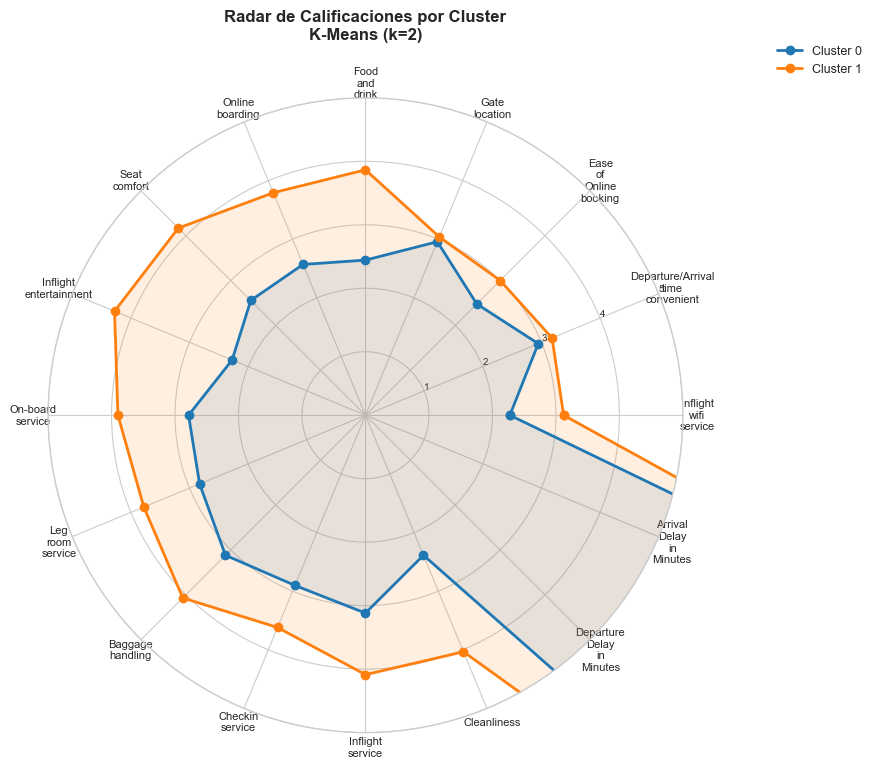

In [150]:
# Variables de calificación (escala 0-5) para radar
rating_cols_eval = [c for c in cols_num_eval if c not in
                    ['Age', 'Flight Distance',
                     'Departure Delay in Minutes (log)', 'Arrival Delay in Minutes (log)']]

perfil_rating = df_eval_clean.groupby('Cluster')[rating_cols_eval].mean()

# Radar
angles = np.linspace(0, 2 * np.pi, len(rating_cols_eval), endpoint=False).tolist()
angles += angles[:1]  # cerrar polígono

colors_radar = sns.color_palette('tab10', n_clusters_best)

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, cluster_id in enumerate(sorted(perfil_rating.index)):
    values = perfil_rating.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i],
            label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.12, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace(' ', '\n') for c in rating_cols_eval], size=8)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1','2','3','4','5'], size=7)
ax.set_title(f'Radar de Calificaciones por Cluster\n{best_model_name}',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()


# 6. Análisis de Resultados

A continuación se responden las preguntas planteadas en el laboratorio con base en los resultados obtenidos.


### Pregunta 1 - Restricciones de Algoritmos y Su Impacto en Calidad

Cada uno de los algoritmos evaluados presenta restricciones propias que afectan tanto el comportamiento del modelo como la calidad de los clusters obtenidos. En el caso de K-Means, la principal limitación es que requiere definir previamente el número de grupos (`k`) y asume que los clusters tienen una forma relativamente esférica y tamaños similares. Esto puede dificultar la detección de estructuras complejas; sin embargo, en este laboratorio permitió generar dos segmentos equilibrados y fáciles de interpretar, lo cual resultó valioso desde la perspectiva del negocio.

Agglomerative Clustering mostró una fuerte sensibilidad a valores atípicos y a la forma en que se construyen las jerarquías entre puntos. Aunque obtuvo un *Silhouette Score* muy alto, el resultado fue engañoso, ya que prácticamente aisló un único pasajero y agrupó los demás registros en un solo cluster. Esto demuestra que una métrica elevada no siempre implica una solución útil o realista.

Por su parte, DBSCAN depende considerablemente de los parámetros `eps` y `min_samples`, además de verse afectado por espacios de alta dimensionalidad generados por variables codificadas. Aunque logró identificar ruido y anomalías, produjo clusters demasiado desbalanceados, dificultando su aplicación para segmentación estratégica de pasajeros.

### Pregunta 2 - Criterios de Importancia para Selección del Algoritmo

La selección del algoritmo no debe basarse únicamente en métricas matemáticas, sino también en la utilidad práctica de los resultados obtenidos. En este caso, los criterios más importantes fueron la interpretabilidad de los clusters, la estabilidad de las agrupaciones, la coherencia con el contexto del negocio y las métricas internas de validación.

K-Means fue seleccionado porque logró un equilibrio adecuado entre desempeño cuantitativo y utilidad organizacional. Los grupos generados eran comprensibles, presentaban tamaños razonables y permitían identificar perfiles claros de pasajeros. Aunque otros algoritmos obtuvieron mejores métricas en ciertos indicadores, sus resultados no fueron suficientemente útiles para la toma de decisiones dentro de VuelaAlpes.

También se consideró importante la eficiencia computacional y la facilidad de explicación del modelo. En contextos empresariales, un modelo ligeramente menos preciso puede ser preferible si produce segmentos fáciles de comunicar y utilizar por diferentes áreas de la organización.

### Pregunta 3 - Medición de Calidad en Clustering

La calidad de los modelos de agrupación fue medida mediante métricas internas como *Silhouette Score*, *Calinski-Harabasz* y *Davies-Bouldin*. Estas métricas permiten evaluar qué tan compactos son los clusters y qué tan separados se encuentran entre sí.

Sin embargo, este laboratorio evidenció que las métricas no deben analizarse de forma aislada. Agglomerative Clustering obtuvo un *Silhouette Score* extremadamente alto, pero el resultado no era útil debido a la distribución poco realista de los grupos. Por el contrario, K-Means presentó métricas más moderadas, aunque generó clusters mucho más coherentes y aplicables desde la perspectiva del negocio.

Por esta razón, se concluye que un modelo tiene buena calidad cuando combina resultados cuantitativos razonables con interpretaciones consistentes y accionables. La validación cualitativa de los clusters es tan importante como los indicadores numéricos, especialmente en problemas de segmentación empresarial.

### Pregunta 4 - Variación de Calidad Entre Algoritmos

La calidad de la solución varió considerablemente entre algoritmos porque cada técnica utiliza criterios distintos para construir los grupos. K-Means optimiza la distancia respecto a centroides, Agglomerative crea estructuras jerárquicas y DBSCAN identifica regiones densas separadas por zonas dispersas.

Estas diferencias generan resultados muy distintos incluso utilizando el mismo conjunto de datos. Mientras K-Means produjo segmentos balanceados y fáciles de interpretar, Agglomerative generó una separación extrema y DBSCAN identificó densidades difíciles de convertir en perfiles comerciales útiles.

Esto demuestra que no existe un algoritmo universalmente superior para todos los problemas. La calidad final depende tanto de la naturaleza de los datos como de los objetivos del análisis. En este caso, la estructura de los datos de pasajeros favoreció a K-Means porque permitió encontrar patrones comprensibles relacionados con satisfacción, tipo de viaje y experiencia del cliente.

#### Comparativa de Resultados Cuantitativos

| Métrica | K-Means | Agglomerative | DBSCAN |
|---------|---------|---------------|--------|
| **Clusters encontrados** | 2 | 2 | 3 + 141 ruido |
| **Silhouette** | 0.1404 | 0.8284 | 0.3217 |
| **Calinski-Harabasz** | 1644.83 | 64.03 | 17.98 |
| **Davies-Bouldin** | 2.3789 | 0.1215 | 0.7519 |
| **Tamaño Cluster Mayor** | 54.3% | 99.9% | 98.5% |
| **Tamaño Cluster Menor** | 45.7% | 0.01% | 0.03% |


### Pregunta 5 - Interpretación de Resultados de Agrupación

La interpretación de los resultados se realizó analizando las características promedio de cada cluster y relacionándolas con el contexto operativo de VuelaAlpes. El modelo K-Means identificó dos segmentos principales de pasajeros con comportamientos claramente diferenciados.

El primer cluster agrupa pasajeros de vuelos más cortos, predominantemente en clase económica y con niveles de satisfacción relativamente bajos en variables relacionadas con comodidad, entretenimiento y servicio. Este grupo representa una oportunidad importante de mejora para la aerolínea, especialmente en estrategias de experiencia del cliente.

El segundo cluster corresponde a pasajeros con trayectos más largos y mayores niveles de satisfacción general. Estos pasajeros presentan una percepción más positiva del servicio y pueden asociarse a clientes premium o viajeros frecuentes, por lo que representan un segmento estratégico para programas de fidelización y retención.

En conjunto, los resultados permiten comprender mejor los perfiles de pasajeros y proporcionan información útil para orientar decisiones comerciales, mejorar servicios específicos y diseñar estrategias diferenciadas según las necesidades de cada segmento identificado.

# 7. Video

Video Recomendaciones[]

# 8. Registro del Uso de IA Generativa

## Herramienta utilizada
**Claude (Anthropic) - claude-sonnet-4-6**, accedido a través de claude.ai.

**Tipos de uso:**
- Generación de estructura inicial y esqueleto de código para las secciones del laboratorio
- Apoyo en la escritura de celdas de exploración y visualización
- Consultas conceptuales sobre algoritmos de clustering y métricas de evaluación
- Revisión de decisiones de preprocesamiento

## Prompts principales utilizados

1. *"Tengo que hacer este laboratorio [adjunto enunciado]. Me ayudarías a empezar por las librerías y la exploración de los datos, donde debo realizar una exploración completa identificando problemas en completitud, unicidad, consistencia y validez..."*

2. *"Continúa con los tres algoritmos de agrupación (K-Means, Agglomerative y DBSCAN) con búsqueda de hiperparámetros y pipelines reproducibles."*

3. *"Faltan las secciones de selección del mejor modelo, evaluación cualitativa y análisis de resultados."*


## Análisis crítico del resultado

**¿Qué partes del contenido generado fueron correctas y útiles?**
La IA generó correctamente la estructura general del pipeline de preprocesamiento con `ColumnTransformer`, la lógica del k-distance plot para DBSCAN y la función auxiliar `evaluar_modelo` que centraliza el cálculo de las tres métricas. Las visualizaciones (heatmaps de centroides, radar chart) fueron una adición valiosa que no estaba en el enunciado original.

**¿Qué errores o imprecisiones se identificaron?**
- En una versión inicial, el notebook usaba `sep=';'` para cargar el CSV cuando el separador real era `,`. Fue necesario corregirlo tras inspeccionar el archivo.
- La IA generó inicialmente un pipeline que intentaba aplicar `predict()` sobre `AgglomerativeClustering`, que no dispone de este método. Se corrigió para usar `fit_predict()` directamente sobre `X_prep`.
- Las celdas de exploración genéricas (detectar columnas automáticamente) debieron adaptarse a los nombres reales de las columnas del dataset de VuelaAlpes.

**¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IA?**
- La transformación logarítmica de los delays (`log(1+x)`) fue una decisión propia al observar los histogramas reales con valores hasta 930 minutos; la IA inicialmente proponía solo recortar outliers con `clip()`.
- La decisión de conservar los ceros en las calificaciones (en lugar de imputarlos) fue validada contra el diccionario de datos y el contexto del negocio.


## Aportes propios del estudiante

- Inspección manual del dataset para detectar el separador correcto y la distribución real de las variables.
- Validación de que los ceros en calificaciones tienen significado semántico (servicio no disponible), no son errores.
- Ajuste del rango de búsqueda de `eps` en DBSCAN basado en el k-distance plot real.
- Redacción de las interpretaciones cualitativas de los clusters con referencia explícita a los objetivos de negocio de VuelaAlpes (innovación, capacitación, calidad).
- Respuesta a las cinco preguntas de análisis de resultados con justificación propia basada en los conceptos del curso.
